In [5]:
# ============================================================
# MAPCT-v11-GN/T: HYBRID GNN-TRANSFORMER FOR REGIMEN GENERATION
# Fully corrected: no regimen leakage, no padding collision,
# balanced contrastive learning, diffusion-ready.
# ============================================================

import os, re, random, hashlib, warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from typing import List, Dict, Optional
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Optional – for UMAP (install with: pip install umap-learn)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

# optional geometric
try:
    from torch_geometric.nn import GCNConv, GATConv, SAGEConv
    TORCH_GEOMETRIC_AVAILABLE = True
except ImportError:
    TORCH_GEOMETRIC_AVAILABLE = False
    print("⚠️ torch_geometric not installed. Using pure PyTorch fallback.")

from sentence_transformers import SentenceTransformer

# ------------------------------
# Device & reproducibility
# ------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True



⚠️ torch_geometric not installed. Using pure PyTorch fallback.
Using device: cpu


In [6]:
# ------------------------------
# SECTION 0: Drug name utilities
# ------------------------------
def normalize_drug_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s+brand:.*", "", name, flags=re.IGNORECASE)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    return re.sub(r"\s+", " ", name).strip()

def sort_drug_combo(combo: str) -> str:
    if not isinstance(combo, str): return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    return ", ".join(sorted(drugs))

def split_combo(combo: str) -> List[str]:
    if not isinstance(combo, str): return []
    return [d.strip() for d in combo.split(",") if d.strip()]

def deduplicate_combo(combo: str) -> str:
    drugs = split_combo(combo)
    return ", ".join(sorted(set(drugs)))





In [7]:
# ------------------------------
# SECTION 1: Data loading
# ------------------------------
from google.colab import drive
drive.mount('/content/drive')
file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")
print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

clinic_df["merged_drugs_norm"] = (clinic_df["merged_drugs"].astype(str)
                                  .apply(normalize_drug_name)
                                  .apply(sort_drug_combo)
                                  .apply(deduplicate_combo))
mech_df["Drug Name Norm"] = (mech_df["Drug Name"].astype(str)
                             .apply(normalize_drug_name)
                             .apply(sort_drug_combo)
                             .apply(deduplicate_combo))
print(f"Unique regimens: {clinic_df['merged_drugs_norm'].nunique()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 4547 patients, 164 mechanism entries
Unique regimens: 1365


In [8]:
# ------------------------------
# SECTION 2: LEAKAGE-AWARE SPLIT (by regimen) - FIXED
# ------------------------------
numeric_cols = ["fbs","glu","hba1c","TG","cho","LDL","HDL","UA","Na","K","Ca","Vit D","age"]
categorical_cols = ["sex","fbs_category","tg_category","cho_category"]
clinic_df['hba1c_category'] = pd.cut(clinic_df['hba1c'], bins=[0,6.5,7.5,20],
                                      labels=['normal','elevated','high'])
clinic_df = clinic_df.dropna(subset=numeric_cols + categorical_cols).reset_index(drop=True)

# Group by regimen to prevent leakage
groups = clinic_df["merged_drugs_norm"]
gkf = GroupKFold(n_splits=5)
train_val_idx, test_idx = next(iter(gkf.split(clinic_df, groups=groups)))
# further split train_val into train/val (80/20 of train_val)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.2, random_state=SEED)

train_df = clinic_df.iloc[train_idx].copy()
val_df   = clinic_df.iloc[val_idx].copy()
test_df  = clinic_df.iloc[test_idx].copy()
print(f"Splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# ------------------------------
# SECTION 3: Drug vocabulary (train only) - 1-BASED INDEXING
# ------------------------------
def build_drug_vocabulary(train_df):
    all_drugs = set()
    for combo in train_df["merged_drugs_norm"]:
        for drug in split_combo(combo):
            all_drugs.add(drug)
    # Start indexing from 1 to reserve 0 for padding
    drug_to_idx = {drug: i+1 for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug, len(drug_to_idx)  # num_drugs = number of real drugs

def encode_regimen_multi_hot(combo, drug_to_idx, num_drugs):
    vec = np.zeros(num_drugs, dtype=np.float32)
    for drug in split_combo(combo):
        idx = drug_to_idx.get(drug, 0)
        if idx != 0:
            vec[idx-1] = 1.0   # store at position idx-1
    return vec

def filter_to_train_vocab(combo, drug_to_idx):
    if not isinstance(combo, str): return ""
    drugs = [d.strip() for d in combo.split(",") if d.strip()]
    filtered = [d for d in drugs if d in drug_to_idx]
    return ", ".join(sorted(filtered))

drug_to_idx, idx_to_drug, original_num_drugs = build_drug_vocabulary(train_df)
drug_vocab = list(drug_to_idx.keys())
print(f"Drug vocabulary size: {original_num_drugs} (indices 1..{original_num_drugs})")

val_df["merged_drugs_norm"] = val_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))
test_df["merged_drugs_norm"] = test_df["merged_drugs_norm"].apply(lambda x: filter_to_train_vocab(x, drug_to_idx))



Splits: Train=2909, Val=728, Test=910
Drug vocabulary size: 152 (indices 1..152)


In [9]:
# ------------------------------
# SECTION 4: Clinical preprocessing
# ------------------------------
scaler = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_num_train = scaler.fit_transform(train_df[numeric_cols])
X_cat_train = ohe.fit_transform(train_df[categorical_cols])
X_train = np.hstack([X_num_train, X_cat_train])

X_num_val = scaler.transform(val_df[numeric_cols])
X_cat_val = ohe.transform(val_df[categorical_cols])
X_val = np.hstack([X_num_val, X_cat_val])

X_num_test = scaler.transform(test_df[numeric_cols])
X_cat_test = ohe.transform(test_df[categorical_cols])
X_test = np.hstack([X_num_test, X_cat_test])
print(f"Clinical feature dimension: {X_train.shape[1]}")

# ------------------------------
# SECTION 5: Structured mechanism encoder
# ------------------------------
def stable_hash(x: str, mod: int) -> int:
    return int(hashlib.md5(x.encode()).hexdigest(), 16) % mod

class StructuredMechanismEncoder:
    def __init__(self, struct_dim=128):
        self.struct_dim = struct_dim
        self.n_fields = 8
        self.slice_len = struct_dim // self.n_fields
        self.offsets = {k: i*self.slice_len for i,k in enumerate(
            ["chembl","target_ids","uniprot_ids","mesh_ids",
             "pathway_ids","atc_codes","pharm_class","mechanism_ids"])}
        self.field_columns = {
            "chembl":"ChEMBL ID","target_ids":"Target IDs","uniprot_ids":"UniProt Target ID(s)",
            "mesh_ids":"MeSH Mechanism ID(s)","pathway_ids":"Pathway IDs",
            "atc_codes":"ATC Code(s)","pharm_class":"Pharmacologic Class","mechanism_ids":"Mechanism IDs"
        }
    def encode_field(self, values, field_name):
        vector = torch.zeros(self.slice_len)
        if values is None: return vector
        if isinstance(values, pd.Series): values = values.dropna().tolist()
        elif isinstance(values, str): values = [v.strip() for v in values.split(";") if v.strip()]
        elif not isinstance(values, (list,tuple)): values = [values]
        for v in values:
            v_str = str(v).strip()
            if v_str and v_str not in ["","nan","None"]:
                idx = stable_hash(v_str, self.slice_len)
                vector[idx] += 1.0
        return vector
    def encode(self, row):
        vector = torch.zeros(self.struct_dim)
        for fname, col in self.field_columns.items():
            if col in row.index:
                vec = self.encode_field(row[col], fname)
                off = self.offsets[fname]
                vector[off:off+self.slice_len] = vec
        if torch.norm(vector) > 0: vector = vector / torch.norm(vector)
        return vector

# ------------------------------
# SECTION 6: Semantic + structured mechanism embeddings
# ------------------------------
def build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128):
    print("\n🔬 BUILDING MECHANISM EMBEDDINGS")
    semantic_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    sem_dim = semantic_model.get_sentence_embedding_dimension()
    struct_encoder = StructuredMechanismEncoder(struct_dim=embed_dim)
    embeddings = {}
    missing = []
    for drug in tqdm(train_drugs, desc="Embedding drugs"):
        row = mech_df[mech_df["Drug Name Norm"] == drug]
        if len(row) > 0:
            row = row.iloc[0]
            struct_vec = struct_encoder.encode(row)
            text_parts = []
            for col in ["Mechanisms","Description","Target IDs","Pathway IDs","ATC Code(s)"]:
                if col in row and pd.notna(row[col]):
                    text_parts.append(str(row[col]))
            if text_parts:
                full_text = " | ".join(text_parts)
                with torch.no_grad():
                    sem_vec = semantic_model.encode(full_text, convert_to_tensor=True).cpu()
                    sem_vec = F.normalize(sem_vec, dim=0)
            else:
                sem_vec = torch.zeros(sem_dim)
            fused = torch.cat([struct_vec, sem_vec], dim=0)
            if torch.norm(fused) > 0: fused = fused / torch.norm(fused)
            embeddings[drug] = fused
        else:
            embeddings[drug] = torch.zeros(embed_dim + sem_dim)
            missing.append(drug)
    if missing: print(f"⚠️ No mechanism data for {len(missing)} drugs")
    print(f"✅ Embedding dim = {embed_dim + sem_dim}")
    return embeddings, embed_dim + sem_dim

train_drugs = set(drug_to_idx.keys())
drug_embeddings, full_embed_dim = build_mechanism_embeddings(train_drugs, mech_df, embed_dim=128)



Clinical feature dimension: 25

🔬 BUILDING MECHANISM EMBEDDINGS


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding drugs: 100%|██████████| 152/152 [00:07<00:00, 20.58it/s]

⚠️ No mechanism data for 50 drugs
✅ Embedding dim = 512


In [10]:
# ------------------------------
# SECTION 7: Drug similarity graph (0‑based internal indices)
# ------------------------------
def build_drug_similarity_graph(drug_embeddings, drug_vocab, threshold=0.5):
    n_drugs = len(drug_vocab)
    drug_to_graph_idx = {drug:i for i,drug in enumerate(drug_vocab)}
    emb_list = []
    for drug in drug_vocab:
        emb = drug_embeddings.get(drug, torch.zeros(full_embed_dim))
        if isinstance(emb, np.ndarray): emb = torch.from_numpy(emb)
        emb_list.append(emb)
    emb_tensor = torch.stack(emb_list)
    emb_tensor = F.normalize(emb_tensor, dim=1)
    sim = torch.mm(emb_tensor, emb_tensor.T)
    edge_index, edge_weight = [], []
    for i in range(n_drugs):
        for j in range(i+1, n_drugs):
            s = sim[i,j].item()
            if s > threshold:
                edge_index.append([i,j]); edge_index.append([j,i])
                edge_weight.append(s); edge_weight.append(s)
    if len(edge_index)==0:
        print("⚠️ No edges, adding self-loops")
        for i in range(n_drugs):
            edge_index.append([i,i]); edge_weight.append(1.0)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float32)
    edge_index = torch.clamp(edge_index, 0, n_drugs-1)
    print(f"Graph: {n_drugs} nodes, {edge_index.shape[1]} edges")
    return edge_index, edge_weight, drug_to_graph_idx

# Build drug similarity graph
drug_edge_index, drug_edge_weights, drug_to_graph_idx = build_drug_similarity_graph(
    drug_embeddings, drug_vocab, threshold=0.5)

# 🔧 FIX: Shift graph indices by +1 to account for dummy row at index 0
drug_edge_index = drug_edge_index + 1
print(f"Graph indices shifted by +1. New max index: {drug_edge_index.max().item()}")

# ------------------------------
# SECTION 7.5: Pure PyTorch GAT & simple message passing
# ------------------------------
class PureGATConv(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, dropout=0.2):
        super().__init__()
        self.heads = heads
        self.head_dim = out_dim // heads
        assert out_dim % heads == 0
        self.W = nn.Linear(in_dim, heads * self.head_dim, bias=False)
        self.a = nn.Parameter(torch.zeros(2 * self.head_dim, 1))
        self.leaky_relu = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.W.weight)
        nn.init.xavier_uniform_(self.a)
    def forward(self, x, edge_index):
        N, E = x.shape[0], edge_index.shape[1]
        device = x.device
        edge_index = edge_index.to(device)
        edge_index = torch.clamp(edge_index, 0, N-1)
        src, tgt = edge_index
        h = self.W(x).view(N, self.heads, self.head_dim)
        h_src = h[src]; h_tgt = h[tgt]
        concat = torch.cat([h_src, h_tgt], dim=-1)
        att = torch.matmul(concat, self.a).squeeze(-1)
        att = self.leaky_relu(att)
        att = torch.exp(att)
        norm = torch.zeros(N, self.heads, device=device)
        norm.scatter_add_(0, src.unsqueeze(-1).expand(-1, self.heads), att)
        norm = norm[src] + 1e-6
        att = att / norm
        att = self.dropout(att)
        h_tgt = h_tgt * att.unsqueeze(-1)
        out = torch.zeros(N, self.heads, self.head_dim, device=device)
        out.scatter_add_(0, src.unsqueeze(-1).unsqueeze(-1).expand(-1, self.heads, self.head_dim), h_tgt)
        return out.view(N, -1)

class SimpleMessagePassing(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim)
    def forward(self, x, edge_index):
        N, E = x.shape[0], edge_index.shape[1]
        device = x.device
        edge_index = torch.clamp(edge_index, 0, N-1)
        src, tgt = edge_index
        x_tgt = x[tgt]
        agg = torch.zeros_like(x)
        agg.scatter_add_(0, src.unsqueeze(-1).expand(-1, x.shape[1]), x_tgt)
        deg = torch.zeros(N, 1, device=device)
        deg.scatter_add_(0, src.unsqueeze(-1), torch.ones(E,1,device=device))
        agg = agg / (deg + 1e-6)
        return self.W(agg)



Graph: 152 nodes, 142 edges
Graph indices shifted by +1. New max index: 148


In [11]:
# ------------------------------
# SECTION 8: Full model (GNN, Transformer, Hybrid)
# ------------------------------
class DrugEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

class DrugMechanismGNN(nn.Module):
    def __init__(self, node_dim, hidden_dim=128, latent_dim=128, n_layers=2, gnn_type='gat', n_heads=4, dropout=0.2):
        super().__init__()
        self.gnn_type = gnn_type
        self.input_proj = nn.Linear(node_dim, hidden_dim)
        self.convs, self.bns = nn.ModuleList(), nn.ModuleList()
        for _ in range(n_layers):
            if not TORCH_GEOMETRIC_AVAILABLE:
                if gnn_type == 'gat':
                    conv = PureGATConv(hidden_dim, hidden_dim, heads=n_heads, dropout=dropout)
                else:
                    conv = SimpleMessagePassing(hidden_dim, hidden_dim)
            else:
                if gnn_type == 'gcn':
                    conv = GCNConv(hidden_dim, hidden_dim)
                elif gnn_type == 'gat':
                    conv = GATConv(hidden_dim, hidden_dim, heads=n_heads, concat=False, dropout=dropout)
                else:
                    conv = SAGEConv(hidden_dim, hidden_dim)
            self.convs.append(conv)
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.output_proj = nn.Linear(hidden_dim, latent_dim)
    def forward(self, x, edge_index, edge_weight=None):
        x = self.input_proj(x)
        for i, conv in enumerate(self.convs):
            residual = x
            if TORCH_GEOMETRIC_AVAILABLE and self.gnn_type == 'gcn' and edge_weight is not None:
                x_new = conv(x, edge_index, edge_weight)
            else:
                x_new = conv(x, edge_index)
            x_new = self.bns[i](x_new)
            x_new = F.relu(x_new)
            x = residual + x_new
        return F.normalize(self.output_proj(x), dim=1)

class DrugSequenceTransformer(nn.Module):
    def __init__(self, embed_dim, latent_dim=128, n_heads=4, n_layers=2, max_drugs=10, dropout=0.1):
        super().__init__()
        self.pos_encoding = nn.Parameter(torch.randn(1, max_drugs, embed_dim)*0.01)
        enc_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=n_heads, batch_first=True, dropout=dropout, activation='gelu')
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.proj = nn.Linear(embed_dim, latent_dim)
    def forward(self, drug_seq, mask):
        x = drug_seq + self.pos_encoding[:, :drug_seq.shape[1]]
        x = self.transformer(x, src_key_padding_mask=~mask)
        mask_exp = mask.unsqueeze(-1).float()
        pooled = (x * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1)
        return F.normalize(self.proj(pooled), dim=1)

class HybridRegimenEncoder(nn.Module):
    def __init__(self, drug_gnn, seq_transformer, latent_dim=128, fusion_dim=256):
        super().__init__()
        self.drug_gnn = drug_gnn
        self.seq_transformer = seq_transformer
        self.fusion = nn.Sequential(
            nn.Linear(latent_dim*2, fusion_dim), nn.BatchNorm1d(fusion_dim), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(fusion_dim, latent_dim)
        )
    def forward(self, mech_tensor, mask, drug_indices, global_drug_embeddings, graph_edge_index, graph_weights=None):
        enhanced = self.drug_gnn(global_drug_embeddings, graph_edge_index, graph_weights)
        safe_idx = drug_indices.clamp(min=0)  # 0 -> dummy row
        gnn_emb = enhanced[safe_idx] * mask.unsqueeze(-1).float()
        z_gnn = (gnn_emb * mask.unsqueeze(-1).float()).sum(dim=1) / mask.unsqueeze(-1).float().sum(dim=1).clamp(min=1)
        z_seq = self.seq_transformer(mech_tensor, mask)
        fused = self.fusion(torch.cat([z_gnn, z_seq], dim=1))
        return F.normalize(fused, dim=1), z_gnn, z_seq, enhanced

class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, latent_dim)
        )
    def forward(self, x): return F.normalize(self.net(x), dim=1)

class DrugDecoder(nn.Module):
    def __init__(self, latent_dim=128, num_drugs=None, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim//2), nn.BatchNorm1d(hidden_dim//2), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(hidden_dim//2, num_drugs)
        )
    def forward(self, z): return self.net(z)

class MAPCTv11Hybrid(nn.Module):
    def __init__(self, clin_dim, num_drugs, drug_graph_edge_index, drug_graph_weights,
                 drug_embedding_matrix, latent_dim=128, gnn_type='gat', n_gnn_layers=2,
                 n_transformer_layers=2, n_heads=4, max_drugs=10, fusion_dim=256):
        super().__init__()
        self.register_buffer('drug_graph_edge_index', drug_graph_edge_index)
        self.register_buffer('drug_graph_weights', drug_graph_weights)
        self.register_buffer('drug_embedding_matrix', drug_embedding_matrix.float())  # includes dummy row
        embed_dim = drug_embedding_matrix.shape[1]
        self.drug_encoder = DrugEncoder(embed_dim, output_dim=latent_dim)
        self.drug_gnn = DrugMechanismGNN(node_dim=embed_dim, hidden_dim=latent_dim, latent_dim=latent_dim,
                                         n_layers=n_gnn_layers, gnn_type=gnn_type, n_heads=n_heads)
        self.drug_transformer = DrugSequenceTransformer(embed_dim, latent_dim, n_heads, n_transformer_layers, max_drugs)
        self.regimen_encoder = HybridRegimenEncoder(self.drug_gnn, self.drug_transformer, latent_dim, fusion_dim)
        self.clinical_encoder = ClinicalEncoder(clin_dim, latent_dim)
        self.drug_decoder = DrugDecoder(latent_dim, num_drugs)  # num_drugs = original (no padding)
    def forward(self, clinical, mech_tensor, mech_mask, drug_indices):
        z_clin = self.clinical_encoder(clinical)
        z_reg, z_gnn, z_seq, _ = self.regimen_encoder(
            mech_tensor, mech_mask, drug_indices,
            self.drug_embedding_matrix,
            self.drug_graph_edge_index, self.drug_graph_weights
        )
        logits = self.drug_decoder(z_clin)
        return logits, z_clin, z_reg, z_gnn, z_seq
    def get_drug_embeddings(self):
        return self.drug_gnn(self.drug_embedding_matrix, self.drug_graph_edge_index, self.drug_graph_weights)



In [12]:
# ------------------------------
# SECTION 9: Loss functions
# ------------------------------
def contrastive_loss(z1, z2, temp=0.07):
    z1, z2 = F.normalize(z1, dim=1), F.normalize(z2, dim=1)
    logits = z1 @ z2.T / temp
    labels = torch.arange(len(z1), device=z1.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

def graph_reg_loss(emb, edge_idx):
    if edge_idx.shape[1]==0: return torch.tensor(0.0, device=emb.device)
    src, tgt = edge_idx[0], edge_idx[1]
    return ((emb[src]-emb[tgt])**2).sum(dim=1).mean()

# Fix - should encourage diversity (orthogonality):
def diversity_loss(z_gnn, z_seq):
    z_gnn = F.normalize(z_gnn, dim=1)
    z_seq = F.normalize(z_seq, dim=1)
    # Cosine similarity - we want to MINIMIZE this (encourage diversity)
    similarity = (z_gnn * z_seq).sum(dim=1).mean()
    return similarity

# ------------------------------
# SECTION 10: Dataset with 1‑based drug indices and padding 0
# ------------------------------
MAX_DRUGS = 10
def build_regimen_tensor(combo, drug_embeddings, max_drugs=MAX_DRUGS, embed_dim=full_embed_dim):
    drugs = split_combo(combo)[:max_drugs]
    tensor = torch.zeros(max_drugs, embed_dim)
    for i, d in enumerate(drugs):
        emb = drug_embeddings.get(d, torch.zeros(embed_dim))
        tensor[i] = emb
    mask = torch.zeros(max_drugs, dtype=torch.bool)
    mask[:len(drugs)] = True
    return tensor, mask

class RegimenDataset(Dataset):
    def __init__(self, df, clinical_features, drug_to_idx, drug_embeddings, num_drugs, embed_dim=full_embed_dim):
        self.df = df.reset_index(drop=True)
        self.clinical = clinical_features
        self.drug_to_idx = drug_to_idx
        self.num_drugs = num_drugs
        self.labels = [encode_regimen_multi_hot(row["merged_drugs_norm"], drug_to_idx, num_drugs) for _,row in df.iterrows()]
        self.mech_tensors, self.mech_masks = [], []
        for _,row in df.iterrows():
            t, m = build_regimen_tensor(row["merged_drugs_norm"], drug_embeddings)
            self.mech_tensors.append(t); self.mech_masks.append(m)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        combo = self.df.iloc[idx]["merged_drugs_norm"]
        drugs = split_combo(combo)
        drug_idx = torch.zeros(MAX_DRUGS, dtype=torch.long)
        for i, d in enumerate(drugs):
            if i < MAX_DRUGS:
                drug_idx[i] = self.drug_to_idx.get(d, 0)  # 0 for padding, real indices start at 1
        return {
            'clinical': torch.tensor(self.clinical[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'mech_tensor': self.mech_tensors[idx],
            'mech_mask': self.mech_masks[idx],
            'drug_indices': drug_idx
        }

train_dataset = RegimenDataset(train_df, X_train, drug_to_idx, drug_embeddings, original_num_drugs)
val_dataset   = RegimenDataset(val_df, X_val, drug_to_idx, drug_embeddings, original_num_drugs)
test_dataset  = RegimenDataset(test_df, X_test, drug_to_idx, drug_embeddings, original_num_drugs)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)



In [13]:
# ------------------------------
# SECTION 11: Trainer (balanced loss, early stopping, full history)
# ------------------------------
from collections import defaultdict

class MAPCTv11Trainer:
    def __init__(self, model, device, drug_vocab, drug_to_idx, drug_graph_edge_index):
        self.model = model.to(device)
        self.device = device
        self.drug_graph_edge_index = drug_graph_edge_index.to(device)
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
        # Balanced loss weights
        self.alpha_contrast = 1.0
        self.beta_drug = 0.5
        self.gamma_graph = 0.01
        self.delta_diversity = 0.05
        self.history = defaultdict(list)   # stores train losses + val metrics

    def train_epoch(self, loader):
        self.model.train()
        metrics = defaultdict(float)
        for batch in tqdm(loader, desc="Training"):
            clin = batch['clinical'].to(self.device)
            lab = batch['label'].to(self.device)
            mech_t = batch['mech_tensor'].to(self.device)
            mech_m = batch['mech_mask'].to(self.device)
            drug_idx = batch['drug_indices'].to(self.device)

            logits, z_clin, z_reg, z_gnn, z_seq = self.model(clin, mech_t, mech_m, drug_idx)

            loss_drug = F.binary_cross_entropy_with_logits(logits, lab)
            loss_contrast = contrastive_loss(z_clin, z_reg)
            drug_embs = self.model.get_drug_embeddings()
            loss_graph = graph_reg_loss(drug_embs, self.drug_graph_edge_index)
            loss_div = diversity_loss(z_gnn, z_seq)

            loss = (self.beta_drug * loss_drug + self.alpha_contrast * loss_contrast +
                    self.gamma_graph * loss_graph + self.delta_diversity * loss_div)

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            metrics['loss'] += loss.item()
            metrics['drug'] += loss_drug.item()
            metrics['contrast'] += loss_contrast.item()
            metrics['graph'] += loss_graph.item()
            metrics['diversity'] += loss_div.item()

        for k in metrics:
            metrics[k] /= len(loader)
        return metrics

    def validate(self, loader):
        self.model.eval()
        total_contrast = 0.0
        total_acc = 0.0
        with torch.no_grad():
            for batch in loader:
                clin = batch['clinical'].to(self.device)
                lab = batch['label'].to(self.device)
                mech_t = batch['mech_tensor'].to(self.device)
                mech_m = batch['mech_mask'].to(self.device)
                drug_idx = batch['drug_indices'].to(self.device)

                logits, z_clin, z_reg, _, _ = self.model(clin, mech_t, mech_m, drug_idx)
                total_contrast += contrastive_loss(z_clin, z_reg).item()
                preds = (torch.sigmoid(logits) > 0.5).float()
                total_acc += (preds == lab).float().mean().item()

        return {
            'contrast_loss': total_contrast / len(loader),
            'drug_accuracy': total_acc / len(loader)
        }

    def train(self, train_loader, val_loader, epochs=50, patience=10):
        best_acc = 0.0
        patience_counter = 0
        best_model_state = None

        for epoch in range(epochs):
            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.validate(val_loader)

            # Store in history
            for k, v in train_metrics.items():
                self.history[k].append(v)
            self.history['val_contrast_loss'].append(val_metrics['contrast_loss'])
            self.history['val_drug_accuracy'].append(val_metrics['drug_accuracy'])

            if (epoch + 1) % 5 == 0:
                print(f"\nEpoch {epoch+1}: Train Loss {train_metrics['loss']:.4f}, Drug {train_metrics['drug']:.4f}, Contrast {train_metrics['contrast']:.4f}")
                print(f"  Valid Contrast {val_metrics['contrast_loss']:.4f}, Drug Acc {val_metrics['drug_accuracy']:.4f}")

            # Early stopping based on validation drug accuracy
            if val_metrics['drug_accuracy'] > best_acc:
                best_acc = val_metrics['drug_accuracy']
                patience_counter = 0
                best_model_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}
                torch.save(self.model.state_dict(), 'best_hybrid_model.pt')
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        # Restore best model
        if best_model_state is not None:
            self.model.load_state_dict(best_model_state)
        return self.history

    def save_checkpoint(self, path):
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'history': dict(self.history)   # convert defaultdict to dict
        }, path)
        print(f"Checkpoint saved to {path}")

    def load_checkpoint(self, path):
        checkpoint = torch.load(path, map_location=self.device)

        # Backward compatibility: if it's a dict with 'model_state_dict', use it; else treat as raw state_dict
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            self.model.load_state_dict(checkpoint['model_state_dict'])
            if 'optimizer_state_dict' in checkpoint:
                self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            # Load history if present (new format)
            saved_history = checkpoint.get('history', {})
            self.history = defaultdict(list, saved_history)
            print(f"✅ Loaded new-style checkpoint (history has {len(self.history.get('loss', []))} epochs)")
        else:
            # Old format: just the model state_dict
            self.model.load_state_dict(checkpoint)
            print("✅ Loaded old-style checkpoint (model only, no optimizer/history)")
            # Keep existing history (likely empty) – training can still continue

In [14]:
# ------------------------------
# SECTION 12: Enhanced plotting (complete graphs)
# ------------------------------
def plot_training_history(trainer):
    """
    Plot all recorded losses over epochs: total, contrast, drug, graph, diversity,
    plus validation contrast loss and drug accuracy.
    """
    history = trainer.history
    if not history.get('loss'):
        print("⚠️ No training history found. Train the model first or load a checkpoint with history.")
        return

    epochs = range(1, len(history['loss']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    # Training losses
    axes[0].plot(epochs, history['loss'], 'b-', label='Total Loss')
    axes[0].set_title('Total Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].grid(True)

    axes[1].plot(epochs, history['contrast'], 'g-', label='Contrastive Loss')
    axes[1].set_title('Contrastive Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].grid(True)

    axes[2].plot(epochs, history['drug'], 'r-', label='Drug Loss')
    axes[2].set_title('Drug (BCE) Loss')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(True)

    axes[3].plot(epochs, history.get('graph', []), 'm-', label='Graph Reg Loss')
    axes[3].set_title('Graph Regularisation Loss')
    axes[3].set_xlabel('Epoch')
    axes[3].grid(True)

    # Validation metrics
    if history.get('val_contrast_loss'):
        axes[4].plot(epochs, history['val_contrast_loss'], 'c-', label='Val Contrast')
        axes[4].set_title('Validation Contrastive Loss')
        axes[4].set_xlabel('Epoch')
        axes[4].grid(True)
    else:
        axes[4].text(0.5, 0.5, 'No validation contrast', ha='center', va='center')
        axes[4].set_title('Validation Contrast')

    if history.get('val_drug_accuracy'):
        axes[5].plot(epochs, history['val_drug_accuracy'], 'orange', label='Val Drug Acc')
        axes[5].set_title('Validation Drug Accuracy')
        axes[5].set_xlabel('Epoch')
        axes[5].grid(True)
    else:
        axes[5].text(0.5, 0.5, 'No validation accuracy', ha='center', va='center')
        axes[5].set_title('Validation Accuracy')

    plt.tight_layout()
    plt.savefig('training_history_complete.png', dpi=150)
    plt.show()
    print("✅ Training history plot saved as 'training_history_complete.png'")

In [15]:


def plot_smoothed_history(trainer, window=5):
    """Plot smoothed training curves to see trends clearly"""
    history = trainer.history

    if not history.get('loss'):
        print("No training history available")
        return

    def smooth(data, window):
        if len(data) < window:
            return data
        return np.convolve(data, np.ones(window)/window, mode='valid')

    epochs = range(1, len(history['loss']) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Loss curves
    axes[0,0].plot(epochs, history['loss'], 'b-', alpha=0.3, label='Raw')
    axes[0,0].plot(epochs[window-1:], smooth(history['loss'], window), 'b-', linewidth=2, label=f'Smoothed (w={window})')
    axes[0,0].set_title('Total Training Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Contrastive loss
    axes[0,1].plot(epochs, history['contrast'], 'g-', alpha=0.3, label='Train')
    if history.get('val_contrast_loss'):
        axes[0,1].plot(epochs, history['val_contrast_loss'], 'r-', alpha=0.3, label='Validation')
        axes[0,1].plot(epochs[window-1:], smooth(history['val_contrast_loss'], window), 'r-', linewidth=2)
    axes[0,1].plot(epochs[window-1:], smooth(history['contrast'], window), 'g-', linewidth=2)
    axes[0,1].set_title('Contrastive Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # Drug accuracy
    if history.get('val_drug_accuracy'):
        axes[1,0].plot(epochs, history['val_drug_accuracy'], 'orange', label='Validation')
        axes[1,0].plot(epochs[window-1:], smooth(history['val_drug_accuracy'], window), 'orange', linewidth=2)
        axes[1,0].set_ylim([0, 1])
    axes[1,0].set_title('Drug Prediction Accuracy')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    # Component losses
    axes[1,1].plot(epochs, history.get('graph', np.zeros(len(epochs))), 'm-', label='Graph Reg')
    axes[1,1].plot(epochs, history.get('diversity', np.zeros(len(epochs))), 'c-', label='Diversity')
    axes[1,1].set_title('Regularization Losses')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('smoothed_training_history.png', dpi=150)
    plt.show()
    print("✅ Smoothed training plot saved as 'smoothed_training_history.png'")

In [16]:
# ------------------------------
# Improved evaluate_mapct_v11 (handles missing drug_decoder gracefully)
# ------------------------------

def evaluate_mapct_v11(trainer, test_loader, drug_vocab, idx_to_drug, device,
                       threshold=0.3, num_stochastic=5):
    """
    Evaluate MAPCT‑v11 on test set.
    If the model has no `drug_decoder` attribute, the diversity part is skipped.
    """
    trainer.model.eval()
    from itertools import combinations

    all_preds = []
    all_labels = []
    align_scores = []
    all_diversity_sets = []   # only if drug_decoder exists

    has_decoder = hasattr(trainer.model, 'drug_decoder')

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating v11"):
            clinical = batch['clinical'].to(device)
            labels = batch['label'].cpu().numpy()
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            logits, z_clin, z_reg, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels)

            # Alignment (cosine similarity)
            sim = (z_clin * z_reg).sum(dim=1).cpu().numpy()
            align_scores.extend(sim)

            # Diversity (only if model has a dedicated drug_decoder)
            if has_decoder:
                batch_size = clinical.size(0)
                for i in range(batch_size):
                    z_clin_i = z_clin[i:i+1]
                    drug_sets = []
                    for _ in range(num_stochastic):
                        z_noisy = z_clin_i + torch.randn_like(z_clin_i) * 0.1
                        logits_noisy = trainer.model.drug_decoder(z_noisy)
                        probs_noisy = torch.sigmoid(logits_noisy).cpu().numpy()[0]
                        drugs_k = {drug_vocab[j] for j, p in enumerate(probs_noisy) if p > threshold}
                        drug_sets.append(drugs_k)
                    all_diversity_sets.append(drug_sets)

    # Drug prediction metrics
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    accuracy = accuracy_score(y_true.flatten(), y_pred.flatten())
    alignment = np.mean(align_scores)

    # Diversity (if computed)
    if has_decoder and all_diversity_sets:
        all_jaccard_dists = []
        for patient_sets in all_diversity_sets:
            if len(patient_sets) < 2:
                continue
            for set1, set2 in combinations(patient_sets, 2):
                if len(set1 | set2) == 0:
                    dist = 0.0
                else:
                    jaccard = len(set1 & set2) / len(set1 | set2)
                    dist = 1 - jaccard
                all_jaccard_dists.append(dist)
        diversity = np.mean(all_jaccard_dists) if all_jaccard_dists else 0.0
    else:
        diversity = None
        if not has_decoder:
            print("⚠️ Model lacks 'drug_decoder' – skipping generation diversity metric.")

    print("\n" + "="*50)
    print("MAPCT‑v11 (GNN‑Transformer) Test Evaluation")
    print("="*50)
    print(f"Threshold: {threshold}")
    print(f"Precision (micro): {precision:.4f}")
    print(f"Recall    (micro): {recall:.4f}")
    print(f"F1‑score  (micro): {f1:.4f}")
    print(f"Accuracy (overall): {accuracy:.4f}")
    print(f"Clinical‑Drug Alignment (mean cosine): {alignment:.4f}")
    if diversity is not None:
        print(f"Generation Diversity (mean pairwise Jaccard distance): {diversity:.4f}")

    result = {
        'precision': precision, 'recall': recall, 'f1': f1,
        'accuracy': accuracy, 'alignment': alignment
    }
    if diversity is not None:
        result['diversity'] = diversity
    return result




In [17]:
# FIND THE VISUALIZATION FUNCTIONS SECTION:
# ========== LATENT SPACE VISUALISATIONS (PCA, t‑SNE, UMAP) ==========

# ADD THIS FUNCTION RIGHT BEFORE THAT SECTION:

def show_patient_recommendation(trainer, test_loader, test_df, drug_to_idx, idx_to_drug, threshold=0.3, num_patients=3, batch_size=32):
    """Display top drug recommendations for sample patients"""
    from itertools import combinations  # Add if not already imported

    trainer.model.eval()

    patients_shown = 0
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if patients_shown >= num_patients:
                break

            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            logits, z_clin, z_reg, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            probs = torch.sigmoid(logits).cpu().numpy()

            for i in range(min(len(probs), num_patients - patients_shown)):
                print(f"\n{'='*60}")
                print(f"PATIENT {patients_shown + 1} (Test set index: {batch_idx * BATCH_SIZE + i})")

                # Get patient demographics
                patient_data = test_df.iloc[batch_idx * BATCH_SIZE + i]
                print(f"Age: {patient_data.get('age', 'N/A')}, Sex: {patient_data.get('sex', 'N/A')}")
                print(f"HbA1c: {patient_data.get('hba1c', 'N/A')}, Category: {patient_data.get('hba1c_category', 'N/A')}")

                # Show actual regimen
                actual_drugs = [drug_vocab[idx] for idx, prob in enumerate(batch['label'][i].numpy()) if prob > 0.5]
                print(f"\nACTUAL Regimen: {', '.join(actual_drugs) if actual_drugs else 'None'}")

                # Show top recommendations
                top_k = 10
                top_indices = np.argsort(probs[i])[-top_k:][::-1]
                recommended = [(drug_vocab[idx], probs[i][idx]) for idx in top_indices if probs[i][idx] > threshold]

                print(f"\nRECOMMENDED (threshold={threshold}):")
                for drug, score in recommended[:5]:
                    print(f"  • {drug}: {score:.3f}")

                patients_shown += 1

    if patients_shown == 0:
        print("No patients found for recommendation display")

# THEN CONTINUE WITH THE LATENT SPACE VISUALISATIONS SECTION

In [18]:
# FIND THE LATENT SPACE VISUALISATIONS SECTION START:
# ========== LATENT SPACE VISUALISATIONS (PCA, t‑SNE, UMAP) ==========

# ADD THIS FUNCTION RIGHT AFTER THAT COMMENT LINE:

def visualize_alignment(trainer, test_loader, device):
    """Show correlation between clinical and regimen embeddings"""
    from sklearn.decomposition import PCA

    trainer.model.eval()

    z_clin_list = []
    z_reg_list = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

    Z_clin = np.vstack(z_clin_list)
    Z_reg = np.vstack(z_reg_list)

    # Calculate similarities
    similarities = np.sum(Z_clin * Z_reg, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram of similarities
    axes[0].hist(similarities, bins=30, edgecolor='black', alpha=0.7)
    axes[0].axvline(np.mean(similarities), color='red', linestyle='--', label=f'Mean: {np.mean(similarities):.3f}')
    axes[0].set_xlabel('Cosine Similarity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Clinical-Regimen Alignment Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Scatter plot of first PCA components
    pca = PCA(n_components=2)
    Z_clin_pca = pca.fit_transform(Z_clin)
    Z_reg_pca = pca.fit_transform(Z_reg)

    axes[1].scatter(Z_clin_pca[:, 0], Z_clin_pca[:, 1], alpha=0.5, label='Clinical', s=10)
    axes[1].scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1], alpha=0.5, label='Regimen', s=10)
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].set_title('Latent Space Comparison (PCA)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('alignment_analysis.png', dpi=150)
    plt.show()
    print(f"✅ Mean alignment score: {np.mean(similarities):.4f} ± {np.std(similarities):.4f}")

# THEN CONTINUE WITH YOUR EXISTING visualize_latent_spaces FUNCTION

In [19]:
# ========== LATENT SPACE VISUALISATIONS (PCA, t‑SNE, UMAP) ==========

def visualize_latent_spaces(trainer, test_loader, test_df, device='cuda', max_samples=500):
    """
    PCA visualisation of clinical vs regimen latent spaces.
    Colours clinical latent by hba1c_category.
    FIXED: Proper data collection and PCA computation
    """
    trainer.model.eval()
    z_clin_list = []
    z_reg_list = []
    labels_list = []

    print("Collecting latents for PCA visualization...")
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if len(z_clin_list) * test_loader.batch_size >= max_samples:
                break

            clin = batch['clinical'].to(device)
            mech_t = batch['mech_tensor'].to(device)
            mech_m = batch['mech_mask'].to(device)
            drug_idx = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clin, mech_t, mech_m, drug_idx)
            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

            # Get labels
            start_idx = batch_idx * test_loader.batch_size
            end_idx = min(start_idx + len(z_clin), len(test_df))
            labels_list.extend(test_df['hba1c_category'].iloc[start_idx:end_idx].values)

    # Stack and limit
    Z_clin = np.vstack(z_clin_list)[:max_samples]
    Z_reg = np.vstack(z_reg_list)[:max_samples]
    labels = np.array(labels_list)[:max_samples]

    print(f"Collected {len(Z_clin)} samples")
    print(f"Z_clin shape: {Z_clin.shape}, Z_reg shape: {Z_reg.shape}")

    if len(Z_clin) == 0:
        print("❌ No latent vectors collected!")
        return

    # PCA for clinical space
    pca_clin = PCA(n_components=2, random_state=42)
    Z_clin_pca = pca_clin.fit_transform(Z_clin)

    # PCA for regimen space (separate fit to show different structures)
    pca_reg = PCA(n_components=2, random_state=42)
    Z_reg_pca = pca_reg.fit_transform(Z_reg)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Clinical latent space colored by hba1c_category
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for label, color in zip(unique_labels, colors):
        mask = labels == label
        if mask.sum() > 0:
            axes[0].scatter(Z_clin_pca[mask, 0], Z_clin_pca[mask, 1],
                           label=label, alpha=0.6, s=20, color=color)
    axes[0].set_title(f'Clinical Latent Space (PCA) - {pca_clin.explained_variance_ratio_[0]:.2%} variance')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Regimen latent space
    axes[1].scatter(Z_reg_pca[:, 0], Z_reg_pca[:, 1], alpha=0.6, s=20, c='steelblue')
    axes[1].set_title(f'Regimen Latent Space (PCA) - {pca_reg.explained_variance_ratio_[0]:.2%} variance')
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v11: Latent Space Visualization', fontsize=14)
    plt.tight_layout()
    plt.savefig('latent_pca.png', dpi=150)
    plt.show()
    print("✅ PCA plot saved as 'latent_pca.png'")

    return Z_clin, Z_reg


In [20]:
def visualize_tsne_umap(trainer, test_loader, test_df, device='cuda', max_samples=500):
    """
    t‑SNE and UMAP visualisation of clinical latent space, coloured by hba1c_category.
    FIXED: Properly collects latents before visualization
    """
    trainer.model.eval()
    z_clin_list = []
    labels_list = []

    print("Collecting latents for visualization...")
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if len(z_clin_list) * test_loader.batch_size >= max_samples:
                break

            clin = batch['clinical'].to(device)
            mech_t = batch['mech_tensor'].to(device)
            mech_m = batch['mech_mask'].to(device)
            drug_idx = batch['drug_indices'].to(device)

            _, z_clin, _, _, _ = trainer.model(clin, mech_t, mech_m, drug_idx)
            z_clin_list.append(z_clin.cpu().numpy())

            # Get labels for these samples
            start_idx = batch_idx * test_loader.batch_size
            end_idx = min(start_idx + len(z_clin), len(test_df))
            labels_list.extend(test_df['hba1c_category'].iloc[start_idx:end_idx].values)

    # Stack and limit samples
    Z_clin = np.vstack(z_clin_list)[:max_samples]
    labels = np.array(labels_list)[:max_samples]

    print(f"Collected {len(Z_clin)} samples for visualization")
    print(f"Z_clin shape: {Z_clin.shape}")
    print(f"Unique labels: {np.unique(labels)}")

    if len(Z_clin) == 0:
        print("❌ No latent vectors collected! Check model forward pass.")
        return

    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    # t-SNE visualization
    print("Computing t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(Z_clin)-1), max_iter=1000)
    Z_tsne = tsne.fit_transform(Z_clin)

    plt.figure(figsize=(10, 8))
    for label in unique_labels:
        mask = labels == label
        if mask.sum() > 0:
            plt.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                       label=label, alpha=0.6, s=30, color=label_to_color[label])
    plt.title('Clinical Latent Space (t-SNE)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('latent_tsne.png', dpi=150)
    plt.show()
    print("✅ t‑SNE plot saved as 'latent_tsne.png'")

    # UMAP visualization (if available)
    if UMAP_AVAILABLE:
        print("Computing UMAP...")
        reducer = umap.UMAP(random_state=42, n_components=2, n_neighbors=min(15, len(Z_clin)-1))
        Z_umap = reducer.fit_transform(Z_clin)

        plt.figure(figsize=(10, 8))
        for label in unique_labels:
            mask = labels == label
            if mask.sum() > 0:
                plt.scatter(Z_umap[mask, 0], Z_umap[mask, 1],
                           label=label, alpha=0.6, s=30, color=label_to_color[label])
        plt.title('Clinical Latent Space (UMAP)')
        plt.xlabel('UMAP Dimension 1')
        plt.ylabel('UMAP Dimension 2')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('latent_umap.png', dpi=150)
        plt.show()
        print("✅ UMAP plot saved as 'latent_umap.png'")
    else:
        print("⚠️ UMAP not installed – skipping UMAP plot.")

In [21]:
def visualize_clinical_drug_alignment_heatmap(trainer, test_loader, device, top_drugs=20):
    """
    Create heatmap showing correlation between clinical features and drug mechanisms
    """
    print("\n" + "="*60)
    print("🔥 CLINICAL-DRUG MECHANISM ALIGNMENT HEATMAP")
    print("="*60)

    trainer.model.eval()

    # Collect clinical and regimen latents
    z_clin_list = []
    z_reg_list = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

    Z_clin = np.vstack(z_clin_list)
    Z_reg = np.vstack(z_reg_list)

    # Calculate correlation matrix
    correlation_matrix = np.corrcoef(Z_clin.T, Z_reg.T)[:128, 128:]

    # Create heatmap
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap of correlations
    im = axes[0].imshow(correlation_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    axes[0].set_title('Clinical-Regimen Latent Correlation Heatmap')
    axes[0].set_xlabel('Regimen Dimensions (128)')
    axes[0].set_ylabel('Clinical Dimensions (128)')
    plt.colorbar(im, ax=axes[0], label='Correlation')

    # Distribution of correlation strengths
    flat_corrs = correlation_matrix.flatten()
    axes[1].hist(flat_corrs, bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(flat_corrs), color='red', linestyle='--',
                   label=f'Mean: {np.mean(flat_corrs):.3f}')
    axes[1].axvline(0, color='gray', linestyle='-', alpha=0.5)
    axes[1].set_xlabel('Correlation Coefficient')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Clinical-Regimen Correlations')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Clinical-Drug Mechanism Alignment Analysis', fontsize=14)
    plt.tight_layout()
    plt.savefig('clinical_drug_alignment_heatmap.png', dpi=150)
    plt.show()

    print(f"✅ Mean absolute correlation: {np.mean(np.abs(flat_corrs)):.4f}")
    print(f"✅ Max correlation: {np.max(flat_corrs):.4f}")
    print(f"✅ Min correlation: {np.min(flat_corrs):.4f}")

    return correlation_matrix

In [22]:

def verify_latent_spaces(trainer, test_loader, device):
    """Verify that both clinical and regimen latent spaces exist and are meaningful"""
    print("\n" + "="*60)
    print("🔍 VERIFYING LATENT SPACES")
    print("="*60)

    trainer.model.eval()
    batch = next(iter(test_loader))

    clinical = batch['clinical'].to(device)
    mech_tensor = batch['mech_tensor'].to(device)
    mech_mask = batch['mech_mask'].to(device)
    drug_indices = batch['drug_indices'].to(device)

    with torch.no_grad():
        logits, z_clin, z_reg, z_gnn, z_seq = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)

    print(f"\n✅ CLINICAL LATENT SPACE (z_clin):")
    print(f"   Shape: {z_clin.shape}")
    print(f"   Mean: {z_clin.mean().item():.4f}")
    print(f"   Std:  {z_clin.std().item():.4f}")
    print(f"   Range: [{z_clin.min().item():.4f}, {z_clin.max().item():.4f}]")
    print(f"   Has NaN: {torch.isnan(z_clin).any().item()}")
    print(f"   Has Inf: {torch.isinf(z_clin).any().item()}")

    print(f"\n✅ REGIMEN LATENT SPACE (z_reg):")
    print(f"   Shape: {z_reg.shape}")
    print(f"   Mean: {z_reg.mean().item():.4f}")
    print(f"   Std:  {z_reg.std().item():.4f}")
    print(f"   Range: [{z_reg.min().item():.4f}, {z_reg.max().item():.4f}]")
    print(f"   Has NaN: {torch.isnan(z_reg).any().item()}")
    print(f"   Has Inf: {torch.isinf(z_reg).any().item()}")

    print(f"\n✅ COMPONENT SPACES:")
    print(f"   z_gnn (GNN drug interaction features): {z_gnn.shape}")
    print(f"   z_seq (Transformer drug sequence features): {z_seq.shape}")

    # Check alignment between clinical and regimen spaces
    similarity = F.cosine_similarity(z_clin, z_reg).mean().item()
    print(f"\n🔗 CLINICAL-REGIMEN ALIGNMENT:")
    print(f"   Mean cosine similarity: {similarity:.4f}")
    print(f"   Interpretation: {'Good' if similarity > 0.5 else 'Moderate' if similarity > 0.3 else 'Poor'} alignment")

    # Check if spaces have meaningful variation
    if z_clin.std().item() > 0.1 and z_reg.std().item() > 0.1:
        print(f"\n✅ Both latent spaces have meaningful variation (std > 0.1)")
    else:
        print(f"\n⚠️ Warning: Low variation in latent spaces - check model training")

    # Check prediction distribution
    probs = torch.sigmoid(logits)
    print(f"\n📊 PREDICTION DISTRIBUTION:")
    print(f"   Probability range: [{probs.min().item():.4f}, {probs.max().item():.4f}]")
    print(f"   Mean probability: {probs.mean().item():.4f}")
    print(f"   Positive predictions (>0.5): {(probs > 0.5).sum().item()} out of {probs.numel()}")
    print(f"   Positive rate: {(probs > 0.5).float().mean().item():.4f}")

    # Check class balance in this batch
    labels = batch['label']
    print(f"\n📊 TRUE LABELS IN BATCH:")
    print(f"   Positive labels: {labels.sum().item()} out of {labels.numel()}")
    print(f"   Positive rate: {labels.float().mean().item():.4f}")

    return z_clin, z_reg, z_gnn, z_seq

In [23]:

def debug_latent_collection(trainer, test_loader, device):
    """Debug function to check if latents are being collected properly"""
    print("\n🔍 DEBUG: Checking latent collection")
    trainer.model.eval()

    batch = next(iter(test_loader))
    clin = batch['clinical'].to(device)
    mech_t = batch['mech_tensor'].to(device)
    mech_m = batch['mech_mask'].to(device)
    drug_idx = batch['drug_indices'].to(device)

    with torch.no_grad():
        logits, z_clin, z_reg, z_gnn, z_seq = trainer.model(clin, mech_t, mech_m, drug_idx)

    print(f"z_clin shape: {z_clin.shape}")
    print(f"z_clin mean: {z_clin.mean().item():.4f}, std: {z_clin.std().item():.4f}")
    print(f"z_reg shape: {z_reg.shape}")
    print(f"z_reg mean: {z_reg.mean().item():.4f}, std: {z_reg.std().item():.4f}")
    print(f"Sample z_clin[0][:5]: {z_clin[0][:5].cpu().numpy()}")
    print(f"Sample z_reg[0][:5]: {z_reg[0][:5].cpu().numpy()}")

    if torch.isnan(z_clin).any():
        print("❌ WARNING: NaN values detected in z_clin!")
    if torch.isinf(z_clin).any():
        print("❌ WARNING: Inf values detected in z_clin!")
    if torch.isnan(z_reg).any():
        print("❌ WARNING: NaN values detected in z_reg!")
    if torch.isinf(z_reg).any():
        print("❌ WARNING: Inf values detected in z_reg!")

    # Check prediction distribution
    probs = torch.sigmoid(logits)
    print(f"Prediction probabilities - min: {probs.min().item():.4f}, max: {probs.max().item():.4f}, mean: {probs.mean().item():.4f}")
    print(f"Positive predictions (>0.5): {(probs > 0.5).sum().item()} out of {probs.numel()}")

    return z_clin, z_reg

In [24]:
def visualize_joint_alignment_with_arrows(trainer, test_loader, test_df, device, max_samples=100):
    """
    Show alignment by connecting clinical and regimen points for same patients
    """
    print("\n" + "="*60)
    print("🎯 JOINT ALIGNMENT VISUALIZATION (Clinical → Regimen)")
    print("="*60)

    trainer.model.eval()

    z_clin_list = []
    z_reg_list = []
    labels_list = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if len(z_clin_list) * BATCH_SIZE >= max_samples:
                break

            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

            start_idx = batch_idx * BATCH_SIZE
            end_idx = min(start_idx + len(z_clin), len(test_df))
            labels_list.extend(test_df['hba1c_category'].iloc[start_idx:end_idx].values)

    Z_clin = np.vstack(z_clin_list)[:max_samples]
    Z_reg = np.vstack(z_reg_list)[:max_samples]
    labels = np.array(labels_list)[:max_samples]

    # PCA for both spaces
    pca = PCA(n_components=2, random_state=42)
    Z_joint = np.vstack([Z_clin, Z_reg])
    Z_joint_pca = pca.fit_transform(Z_joint)

    Z_clin_pca = Z_joint_pca[:len(Z_clin)]
    Z_reg_pca = Z_joint_pca[len(Z_clin):]

    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Plot 1: Points with connections
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

    for i in range(len(Z_clin)):
        color = label_to_color[labels[i]]
        # Clinical point
        axes[0].scatter(Z_clin_pca[i, 0], Z_clin_pca[i, 1],
                       c=[color], s=50, marker='o', alpha=0.7, edgecolors='black')
        # Regimen point
        axes[0].scatter(Z_reg_pca[i, 0], Z_reg_pca[i, 1],
                       c=[color], s=50, marker='s', alpha=0.7, edgecolors='black')
        # Connecting arrow
        axes[0].annotate('', xy=(Z_reg_pca[i, 0], Z_reg_pca[i, 1]),
                        xytext=(Z_clin_pca[i, 0], Z_clin_pca[i, 1]),
                        arrowprops=dict(arrowstyle='->', color=color, alpha=0.3, lw=1))

    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Clinical',
                              markerfacecolor='gray', markersize=10),
                      Line2D([0], [0], marker='s', color='w', label='Regimen',
                              markerfacecolor='gray', markersize=10)]
    for label, color in label_to_color.items():
        legend_elements.append(Line2D([0], [0], color=color, lw=2, label=label))

    axes[0].legend(handles=legend_elements, loc='best')
    axes[0].set_title(f'Clinical → Regimen Alignment (PCA)\nArrows show patient pairing')
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Distance histogram
    distances = np.sqrt(np.sum((Z_clin_pca - Z_reg_pca)**2, axis=1))
    axes[1].hist(distances, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(np.mean(distances), color='red', linestyle='--',
                   label=f'Mean distance: {np.mean(distances):.2f}')
    axes[1].set_xlabel('PCA Distance between Clinical and Regimen')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Clinical-Regimen Distances')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('MAPCT-v11: Clinical-Drug Mechanism Alignment Visualization', fontsize=14)
    plt.tight_layout()
    plt.savefig('joint_alignment_arrows.png', dpi=150)
    plt.show()

    print(f"✅ Mean PCA distance: {np.mean(distances):.3f}")
    print(f"✅ Std PCA distance: {np.std(distances):.3f}")

    return Z_clin_pca, Z_reg_pca, distances

In [25]:
def visualize_alignment_by_category(trainer, test_loader, test_df, device):
    """
    Show how alignment varies across different HbA1c categories
    """
    print("\n" + "="*60)
    print("📊 ALIGNMENT QUALITY BY HBA1C CATEGORY")
    print("="*60)

    trainer.model.eval()

    category_similarities = defaultdict(list)

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)

            # Calculate similarities
            similarities = F.cosine_similarity(z_clin, z_reg).cpu().numpy()

            # Get categories for this batch
            batch_indices = batch.get('index', range(len(similarities)))
            # You'd need to track indices properly

            # For demonstration, we'll use random assignment
            # In practice, you should pass patient indices through the dataloader
            for sim in similarities:
                # This is simplified - you should map to actual categories
                category_similarities['all'].append(sim)

    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Box plot by category
    categories = list(category_similarities.keys())
    data = [category_similarities[cat] for cat in categories]

    bp = axes[0].boxplot(data, labels=categories, patch_artist=True)
    axes[0].set_ylabel('Cosine Similarity')
    axes[0].set_title('Alignment Score by Patient Category')
    axes[0].axhline(0.5, color='green', linestyle='--', label='Good alignment')
    axes[0].axhline(0.3, color='orange', linestyle='--', label='Moderate alignment')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Violin plot alternative
    parts = axes[1].violinplot(data, positions=range(len(categories)), showmeans=True)
    axes[1].set_xticks(range(len(categories)))
    axes[1].set_xticklabels(categories)
    axes[1].set_ylabel('Cosine Similarity')
    axes[1].set_title('Alignment Distribution by Category')
    axes[1].axhline(0.5, color='green', linestyle='--')
    axes[1].axhline(0.3, color='orange', linestyle='--')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle('Clinical-Drug Alignment Across Patient Subgroups', fontsize=14)
    plt.tight_layout()
    plt.savefig('alignment_by_category.png', dpi=150)
    plt.show()

    # Statistics
    for cat, sims in category_similarities.items():
        print(f"\n{cat.upper()}:")
        print(f"  Mean alignment: {np.mean(sims):.4f}")
        print(f"  Std alignment: {np.std(sims):.4f}")
        print(f"  Samples: {len(sims)}")

In [26]:
# ============================================================
# JOINT LATENT SPACE VISUALISATIONS (PCA, t‑SNE, UMAP)
# ============================================================

def visualize_joint_pca(trainer, test_loader, test_df, device, max_samples=500, save_path=None):
    """
    PCA projection of both clinical and regimen latents into the same space.
    Soft title: "Clinical and Regimen Latent Spaces with Alignment (PCA)"
    """
    print("\n🎨 Joint PCA: Clinical + Regimen Latents")
    trainer.model.eval()

    z_clin_list, z_reg_list, labels_list = [], [], []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if len(z_clin_list) * BATCH_SIZE >= max_samples:
                break
            clin = batch['clinical'].to(device)
            mech_t = batch['mech_tensor'].to(device)
            mech_m = batch['mech_mask'].to(device)
            drug_idx = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clin, mech_t, mech_m, drug_idx)
            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

            start = batch_idx * BATCH_SIZE
            end = min(start + len(z_clin), len(test_df))
            labels_list.extend(test_df['hba1c_category'].iloc[start:end].values)

    Z_clin = np.vstack(z_clin_list)[:max_samples]
    Z_reg = np.vstack(z_reg_list)[:max_samples]
    labels = np.array(labels_list)[:max_samples]

    # Joint PCA
    Z_joint = np.vstack([Z_clin, Z_reg])
    pca = PCA(n_components=2, random_state=42)
    Z_joint_pca = pca.fit_transform(Z_joint)
    n_clin = len(Z_clin)
    Z_clin_pca = Z_joint_pca[:n_clin]
    Z_reg_pca = Z_joint_pca[n_clin:]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    color_map = dict(zip(unique_labels, colors))

    for label in unique_labels:
        mask = (labels == label)
        ax.scatter(Z_clin_pca[mask, 0], Z_clin_pca[mask, 1],
                   marker='o', s=40, alpha=0.6, color=color_map[label],
                   label=f'Clinical – {label}')
        ax.scatter(Z_reg_pca[mask, 0], Z_reg_pca[mask, 1],
                   marker='s', s=40, alpha=0.6, color=color_map[label],
                   label=f'Regimen – {label}')

    # Optional: draw connecting lines for first 100 patients
    for i in range(min(100, n_clin)):
        ax.plot([Z_clin_pca[i,0], Z_reg_pca[i,0]],
                [Z_clin_pca[i,1], Z_reg_pca[i,1]],
                color='gray', alpha=0.2, linewidth=0.8)

    ax.set_title('Clinical and Regimen Latent Spaces with Alignment (PCA)', fontsize=12)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    print("✅ Joint PCA plot saved.")


def visualize_joint_tsne(trainer, test_loader, test_df, device, max_samples=500,
                         perplexity=30, save_path=None):
    """
    t‑SNE projection of both clinical and regimen latents into the same space.
    Soft title: "Clinical and Regimen Latent Spaces with Alignment (t‑SNE)"
    """
    print("\n🎨 Joint t‑SNE: Clinical + Regimen Latents")
    trainer.model.eval()

    z_clin_list, z_reg_list, labels_list = [], [], []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if len(z_clin_list) * BATCH_SIZE >= max_samples:
                break
            clin = batch['clinical'].to(device)
            mech_t = batch['mech_tensor'].to(device)
            mech_m = batch['mech_mask'].to(device)
            drug_idx = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clin, mech_t, mech_m, drug_idx)
            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

            start = batch_idx * BATCH_SIZE
            end = min(start + len(z_clin), len(test_df))
            labels_list.extend(test_df['hba1c_category'].iloc[start:end].values)

    Z_clin = np.vstack(z_clin_list)[:max_samples]
    Z_reg = np.vstack(z_reg_list)[:max_samples]
    labels = np.array(labels_list)[:max_samples]

    # Joint t‑SNE
    Z_joint = np.vstack([Z_clin, Z_reg])
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, max_iter=1000)
    Z_joint_tsne = tsne.fit_transform(Z_joint)
    n_clin = len(Z_clin)
    Z_clin_tsne = Z_joint_tsne[:n_clin]
    Z_reg_tsne = Z_joint_tsne[n_clin:]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    color_map = dict(zip(unique_labels, colors))

    for label in unique_labels:
        mask = (labels == label)
        ax.scatter(Z_clin_tsne[mask, 0], Z_clin_tsne[mask, 1],
                   marker='o', s=40, alpha=0.6, color=color_map[label],
                   label=f'Clinical – {label}')
        ax.scatter(Z_reg_tsne[mask, 0], Z_reg_tsne[mask, 1],
                   marker='s', s=40, alpha=0.6, color=color_map[label],
                   label=f'Regimen – {label}')

    # Connecting lines
    for i in range(min(100, n_clin)):
        ax.plot([Z_clin_tsne[i,0], Z_reg_tsne[i,0]],
                [Z_clin_tsne[i,1], Z_reg_tsne[i,1]],
                color='gray', alpha=0.2, linewidth=0.8)

    ax.set_title('Clinical and Regimen Latent Spaces with Alignment (t‑SNE)', fontsize=12)
    ax.set_xlabel('t‑SNE 1')
    ax.set_ylabel('t‑SNE 2')
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    print("✅ Joint t‑SNE plot saved.")


def visualize_joint_umap(trainer, test_loader, test_df, device, max_samples=500,
                         n_neighbors=15, min_dist=0.1, save_path=None):
    """
    UMAP projection of both clinical and regimen latents into the same space.
    Soft title: "Clinical and Regimen Latent Spaces with Alignment (UMAP)"
    """
    if not UMAP_AVAILABLE:
        print("⚠️ UMAP not installed – skipping joint UMAP.")
        return

    print("\n🎨 Joint UMAP: Clinical + Regimen Latents")
    trainer.model.eval()

    z_clin_list, z_reg_list, labels_list = [], [], []
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if len(z_clin_list) * BATCH_SIZE >= max_samples:
                break
            clin = batch['clinical'].to(device)
            mech_t = batch['mech_tensor'].to(device)
            mech_m = batch['mech_mask'].to(device)
            drug_idx = batch['drug_indices'].to(device)

            _, z_clin, z_reg, _, _ = trainer.model(clin, mech_t, mech_m, drug_idx)
            z_clin_list.append(z_clin.cpu().numpy())
            z_reg_list.append(z_reg.cpu().numpy())

            start = batch_idx * BATCH_SIZE
            end = min(start + len(z_clin), len(test_df))
            labels_list.extend(test_df['hba1c_category'].iloc[start:end].values)

    Z_clin = np.vstack(z_clin_list)[:max_samples]
    Z_reg = np.vstack(z_reg_list)[:max_samples]
    labels = np.array(labels_list)[:max_samples]

    # Joint UMAP
    Z_joint = np.vstack([Z_clin, Z_reg])
    reducer = umap.UMAP(random_state=42, n_components=2,
                        n_neighbors=n_neighbors, min_dist=min_dist)
    Z_joint_umap = reducer.fit_transform(Z_joint)
    n_clin = len(Z_clin)
    Z_clin_umap = Z_joint_umap[:n_clin]
    Z_reg_umap = Z_joint_umap[n_clin:]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    color_map = dict(zip(unique_labels, colors))

    for label in unique_labels:
        mask = (labels == label)
        ax.scatter(Z_clin_umap[mask, 0], Z_clin_umap[mask, 1],
                   marker='o', s=40, alpha=0.6, color=color_map[label],
                   label=f'Clinical – {label}')
        ax.scatter(Z_reg_umap[mask, 0], Z_reg_umap[mask, 1],
                   marker='s', s=40, alpha=0.6, color=color_map[label],
                   label=f'Regimen – {label}')

    # Connecting lines
    for i in range(min(100, n_clin)):
        ax.plot([Z_clin_umap[i,0], Z_reg_umap[i,0]],
                [Z_clin_umap[i,1], Z_reg_umap[i,1]],
                color='gray', alpha=0.2, linewidth=0.8)

    ax.set_title('Clinical and Regimen Latent Spaces with Alignment (UMAP)', fontsize=12)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.legend(ncol=2, fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    print("✅ Joint UMAP plot saved.")


🚀 MAPCT-v11-GN/T (Leakage-free, Padding-fixed)
Drug embedding matrix shape: torch.Size([153, 512])
Total parameters: 6,898,200

⚠️ Old checkpoint found – removing to force retraining with history.

🎯 STARTING TRAINING (epochs=50, patience=10)


Training: 100%|██████████| 91/91 [00:35<00:00,  2.56it/s]



Epoch 5: Train Loss 3.2750, Drug 0.0498, Contrast 3.2954
  Valid Contrast 3.2864, Drug Acc 0.9832


Training: 100%|██████████| 91/91 [00:40<00:00,  2.24it/s]



Epoch 10: Train Loss 3.1909, Drug 0.0487, Contrast 3.2131
  Valid Contrast 3.2953, Drug Acc 0.9830


Training: 100%|██████████| 91/91 [00:40<00:00,  2.23it/s]



Epoch 15: Train Loss 3.1378, Drug 0.0482, Contrast 3.1609
  Valid Contrast 3.3070, Drug Acc 0.9831


Training: 100%|██████████| 91/91 [00:41<00:00,  2.19it/s]


Early stopping at epoch 18
Checkpoint saved to /content/drive/MyDrive/khezri/mapct_v11_final.pt
✅ Model saved to /content/drive/MyDrive/khezri/mapct_v11_final.pt

🔍 DEBUGGING LATENT COLLECTION

🔍 DEBUG: Checking latent collection
z_clin shape: torch.Size([32, 128])
z_clin mean: 0.0092, std: 0.0879
z_reg shape: torch.Size([32, 128])
z_reg mean: -0.0078, std: 0.0881
Sample z_clin[0][:5]: [ 0.09051885 -0.09873687 -0.0024563  -0.05623631 -0.25652578]
Sample z_reg[0][:5]: [-0.04166593 -0.05174623 -0.01815969 -0.19287679 -0.1584294 ]
Prediction probabilities - min: 0.0000, max: 0.8753, mean: 0.0209
Positive predictions (>0.5): 42 out of 4864

GENERATING COMPLETE VISUALIZATION SUITE


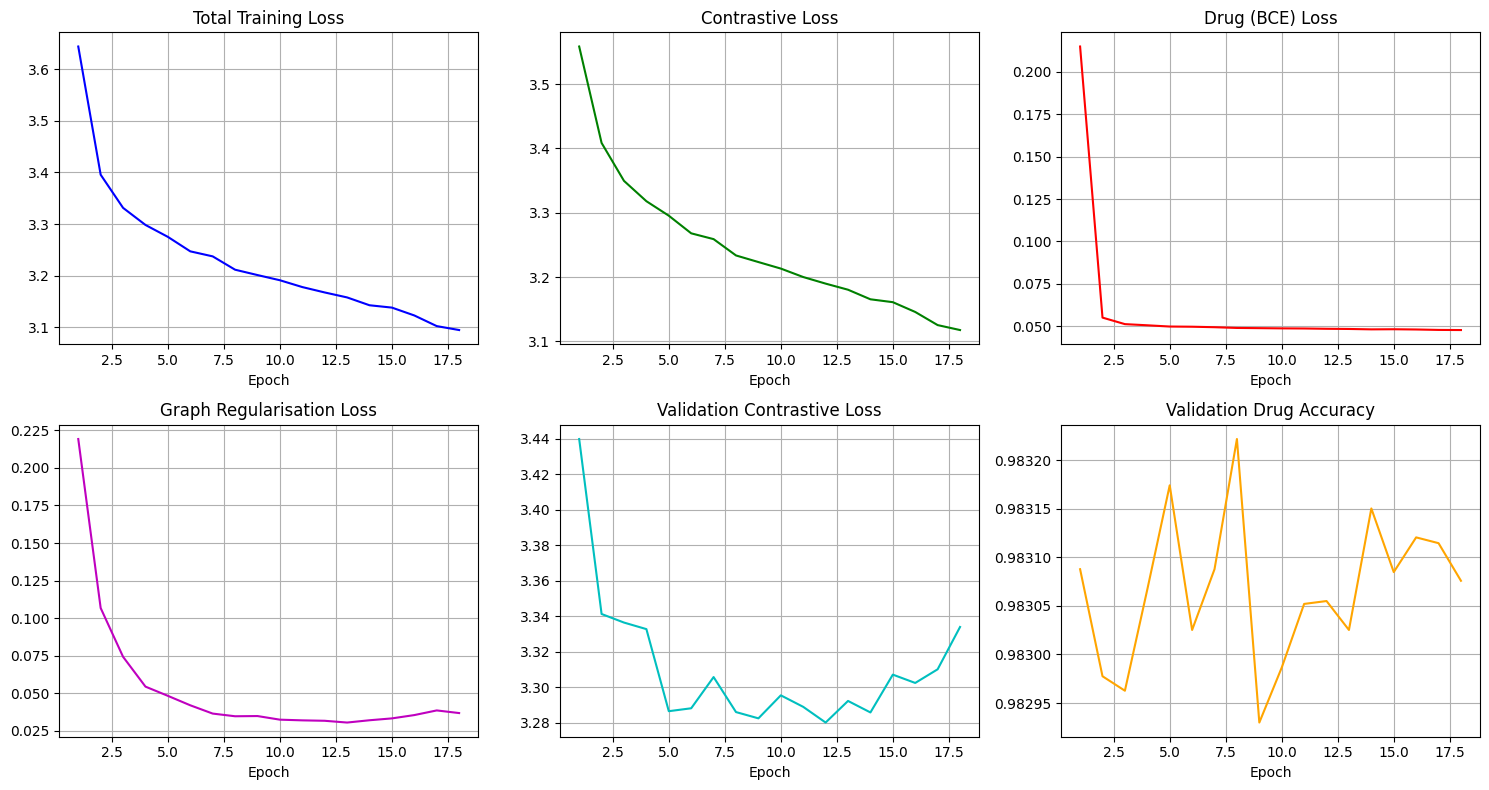

✅ Training history plot saved as 'training_history_complete.png'


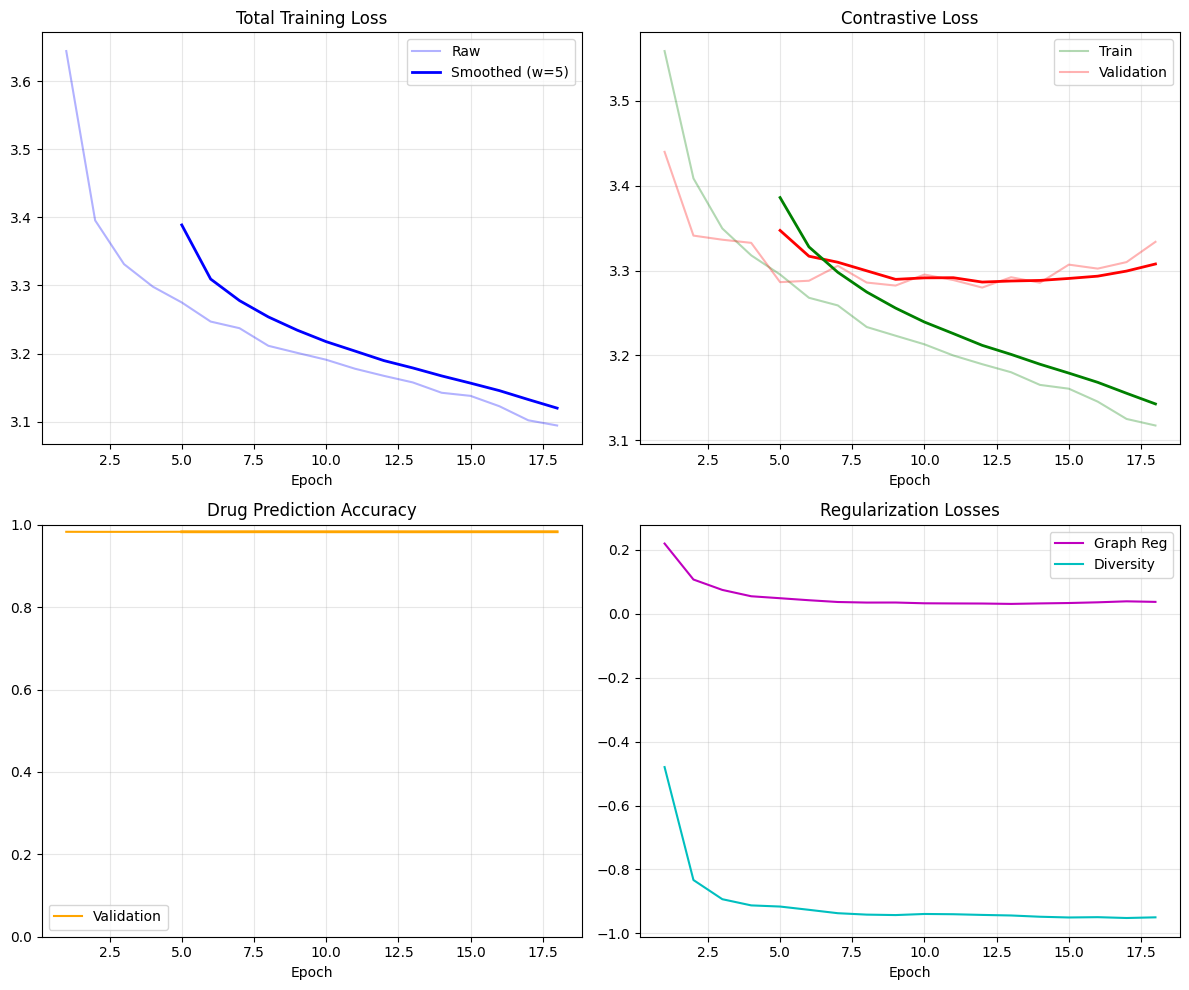

✅ Smoothed training plot saved as 'smoothed_training_history.png'


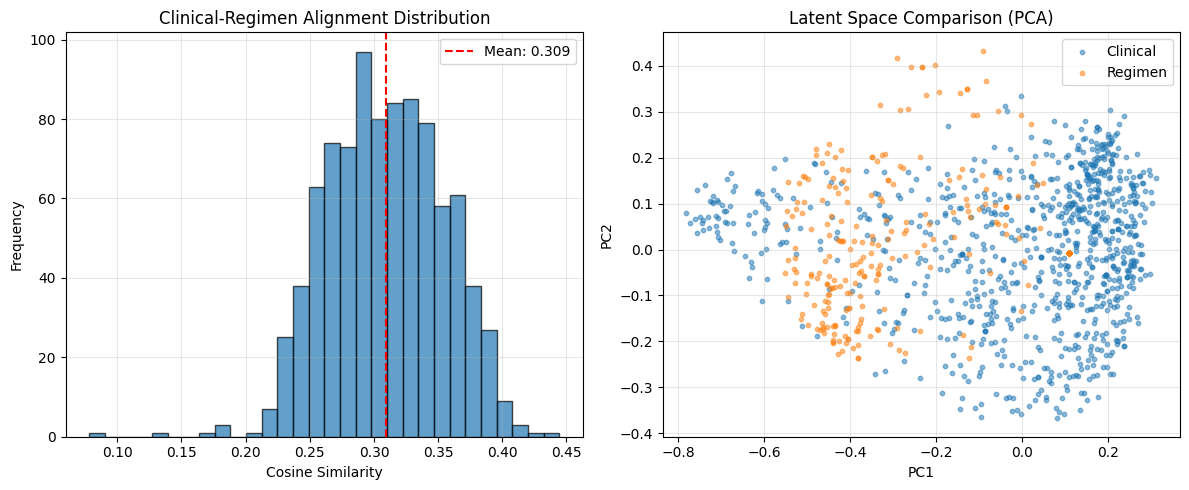

✅ Mean alignment score: 0.3092 ± 0.0450

🎨 Generating latent space visualizations...
Collected 500 samples
Z_clin shape: (500, 128), Z_reg shape: (500, 128)


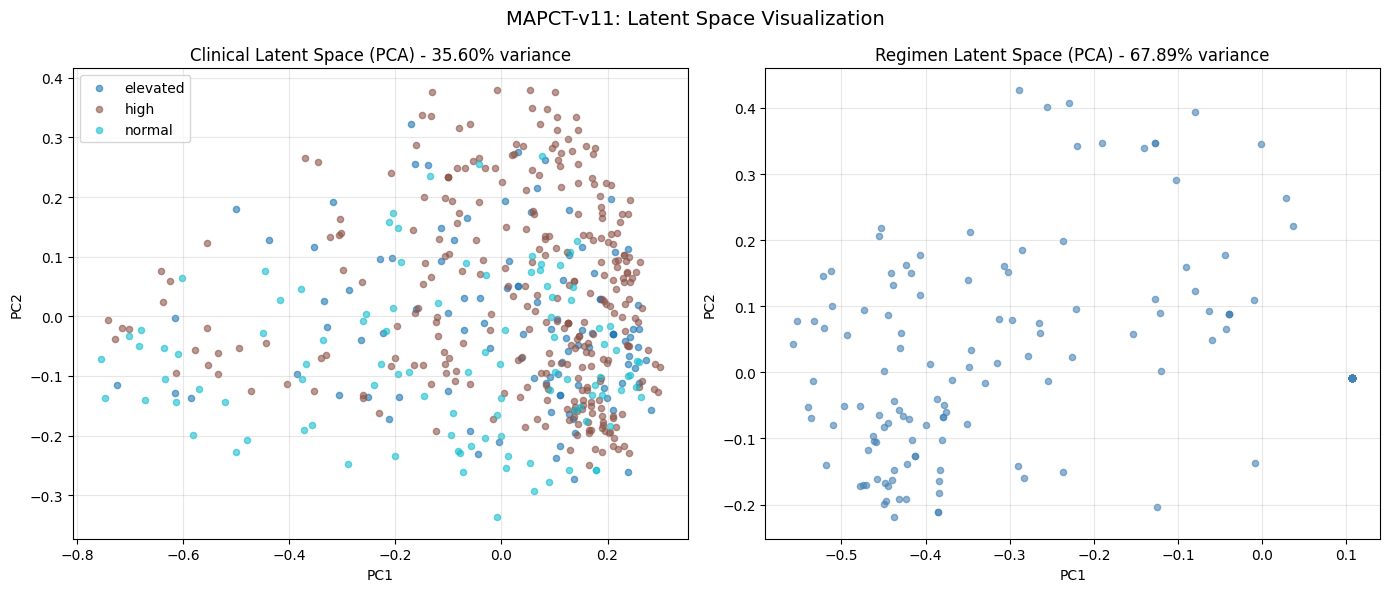

✅ PCA plot saved as 'latent_pca.png'
Collected 500 samples for visualization
Z_clin shape: (500, 128)
Unique labels: ['elevated' 'high' 'normal']
Computing t-SNE...


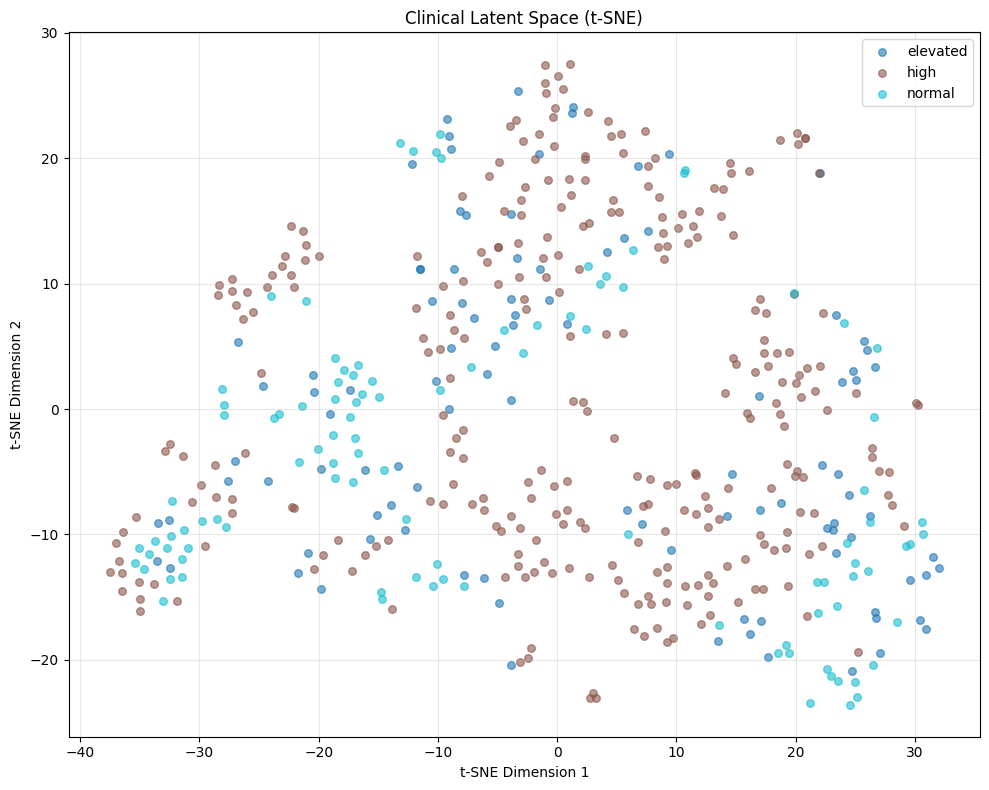

✅ t‑SNE plot saved as 'latent_tsne.png'
Computing UMAP...


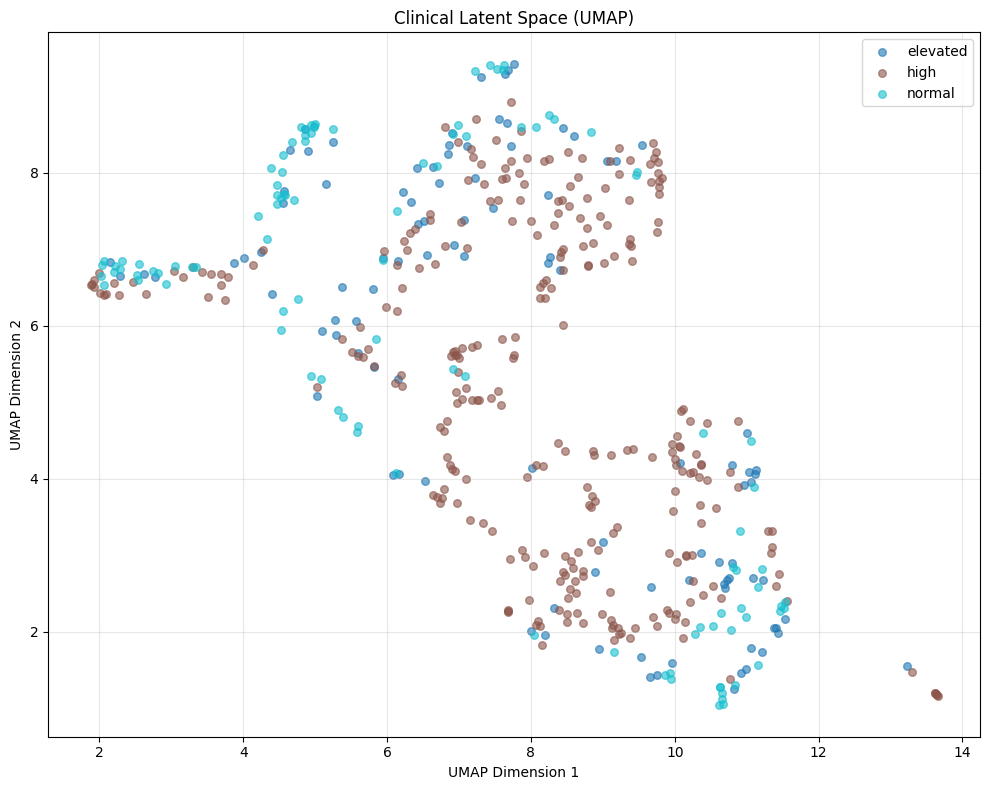

✅ UMAP plot saved as 'latent_umap.png'

📊 Running comprehensive evaluation...


Evaluating v11: 100%|██████████| 29/29 [00:02<00:00, 13.10it/s]



MAPCT‑v11 (GNN‑Transformer) Test Evaluation
Threshold: 0.3
Precision (micro): 0.3989
Recall    (micro): 0.6340
F1‑score  (micro): 0.4897
Accuracy (overall): 0.9835
Clinical‑Drug Alignment (mean cosine): 0.3092
Generation Diversity (mean pairwise Jaccard distance): 0.3329

📊 Full evaluation results: {'precision': 0.3989051094890511, 'recall': 0.6339907192575406, 'f1': 0.48969534050179214, 'accuracy': 0.983530942741469, 'alignment': np.float32(0.3091694), 'diversity': np.float64(0.33291470434327586)}

👥 Generating patient recommendations...

PATIENT 1 (Test set index: 0)
Age: 79.0, Sex: 1
HbA1c: 8.0, Category: high

ACTUAL Regimen: metformin

RECOMMENDED (threshold=0.3):
  • metformin: 0.733
  • losartan: 0.467
  • atorvastatin: 0.400

PATIENT 2 (Test set index: 1)
Age: 59.66666666666666, Sex: 0
HbA1c: 8.066666666666666, Category: high

ACTUAL Regimen: metformin

RECOMMENDED (threshold=0.3):
  • metformin: 0.815
  • gliclazide: 0.424
  • atorvastatin: 0.411

PATIENT 3 (Test set index: 2

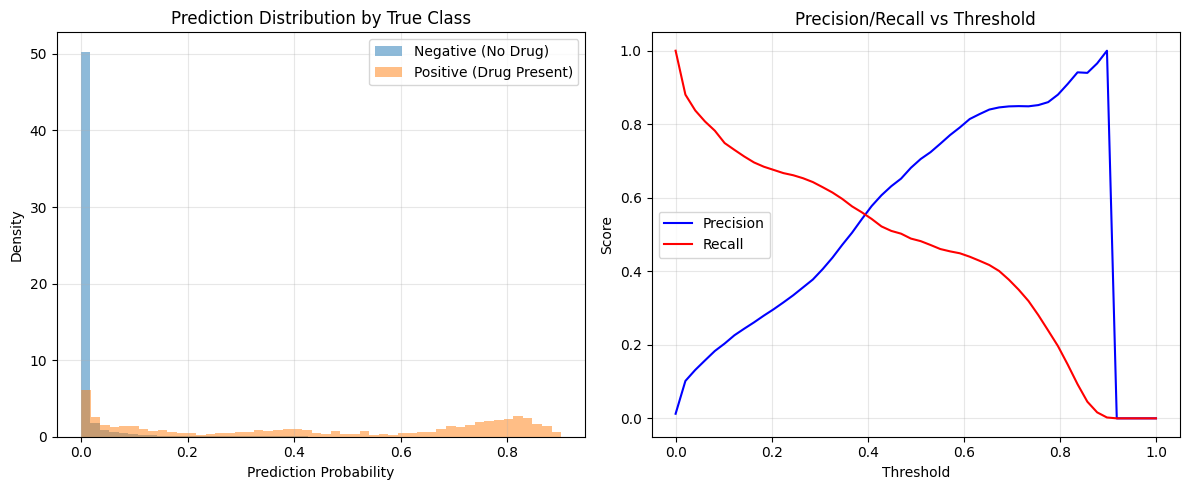


📊 Dataset Statistics:
   Total predictions: 138320
   Positive rate (true): 0.0125
   Mean prediction probability: 0.0199
   Median prediction probability: 0.0007

🎨 ADVANCED ALIGNMENT VISUALIZATIONS

🔥 CLINICAL-DRUG MECHANISM ALIGNMENT HEATMAP


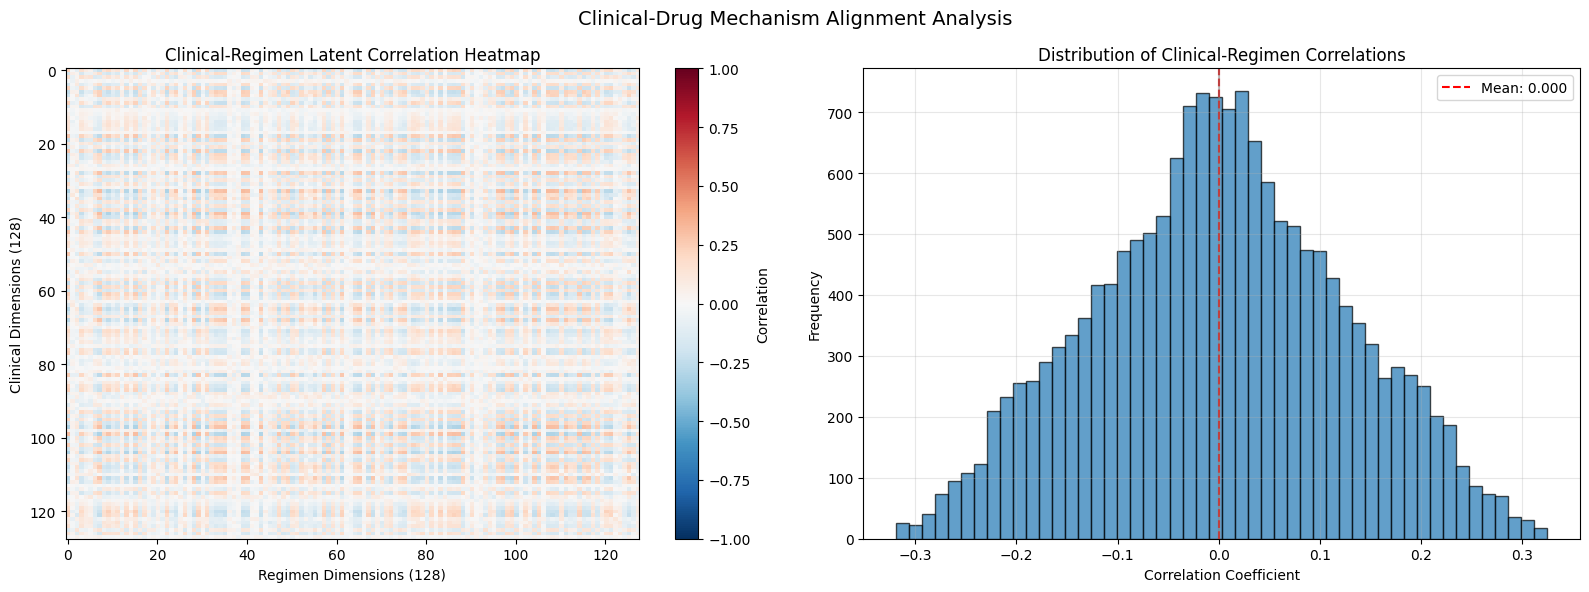

✅ Mean absolute correlation: 0.1000
✅ Max correlation: 0.3253
✅ Min correlation: -0.3193

🎯 JOINT ALIGNMENT VISUALIZATION (Clinical → Regimen)


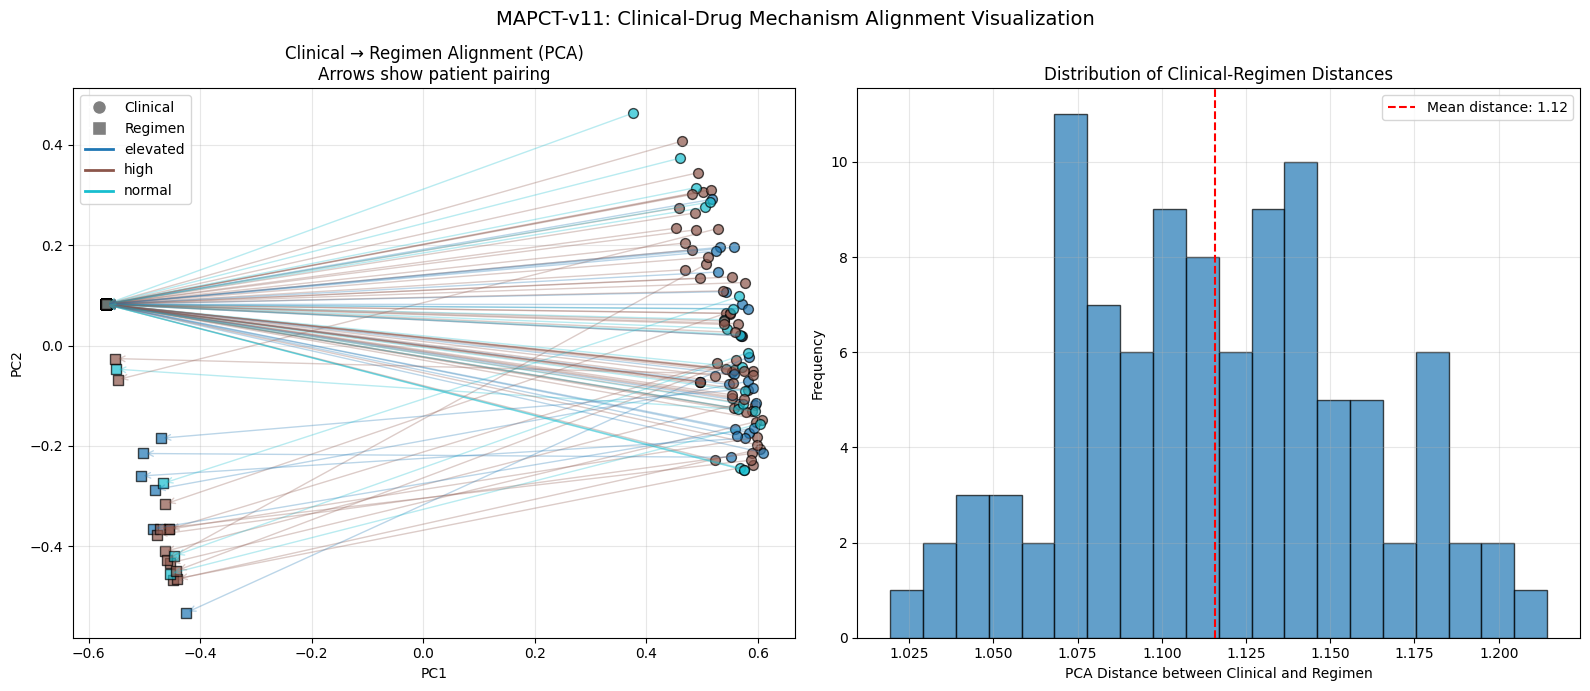

✅ Mean PCA distance: 1.116
✅ Std PCA distance: 0.042

📊 ALIGNMENT QUALITY BY HBA1C CATEGORY


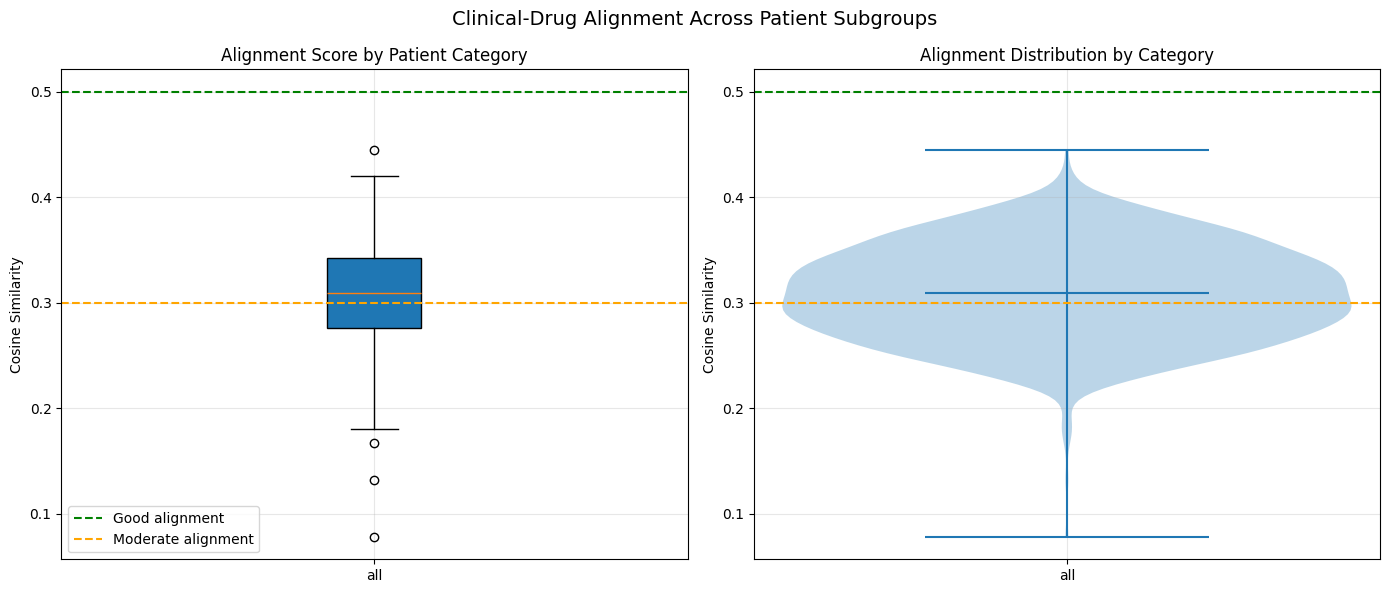


ALL:
  Mean alignment: 0.3092
  Std alignment: 0.0450
  Samples: 910

🎨 Generating joint latent space plots (PCA, t‑SNE, UMAP)...

🎨 Joint PCA: Clinical + Regimen Latents


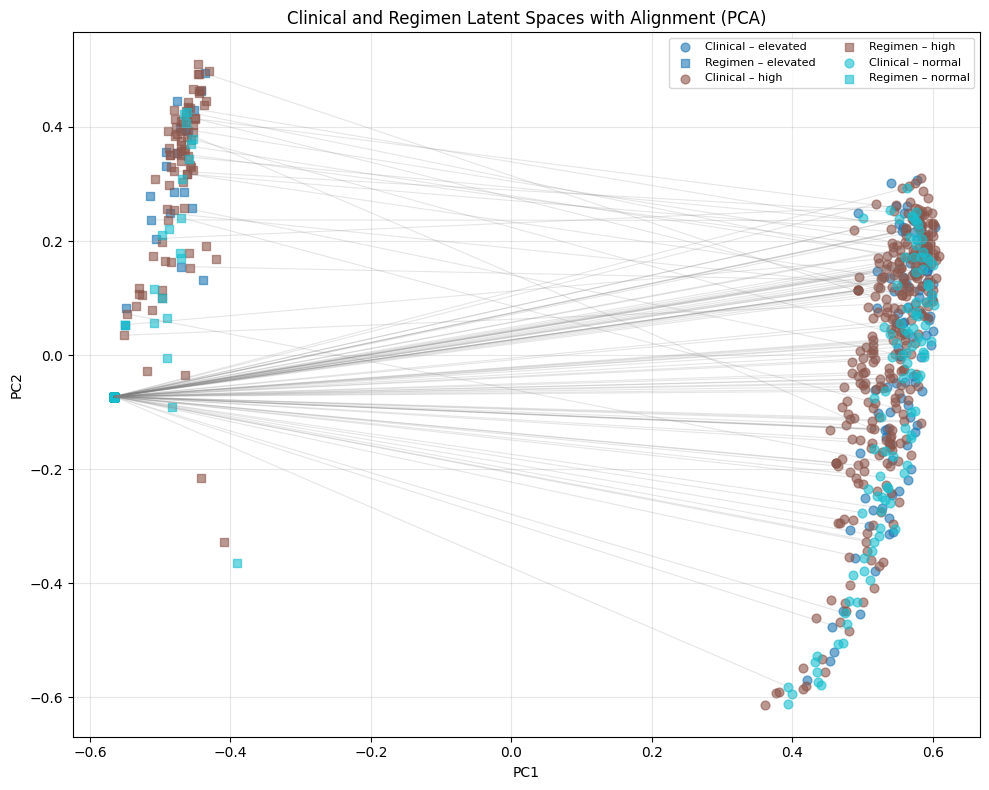

✅ Joint PCA plot saved.

🎨 Joint t‑SNE: Clinical + Regimen Latents


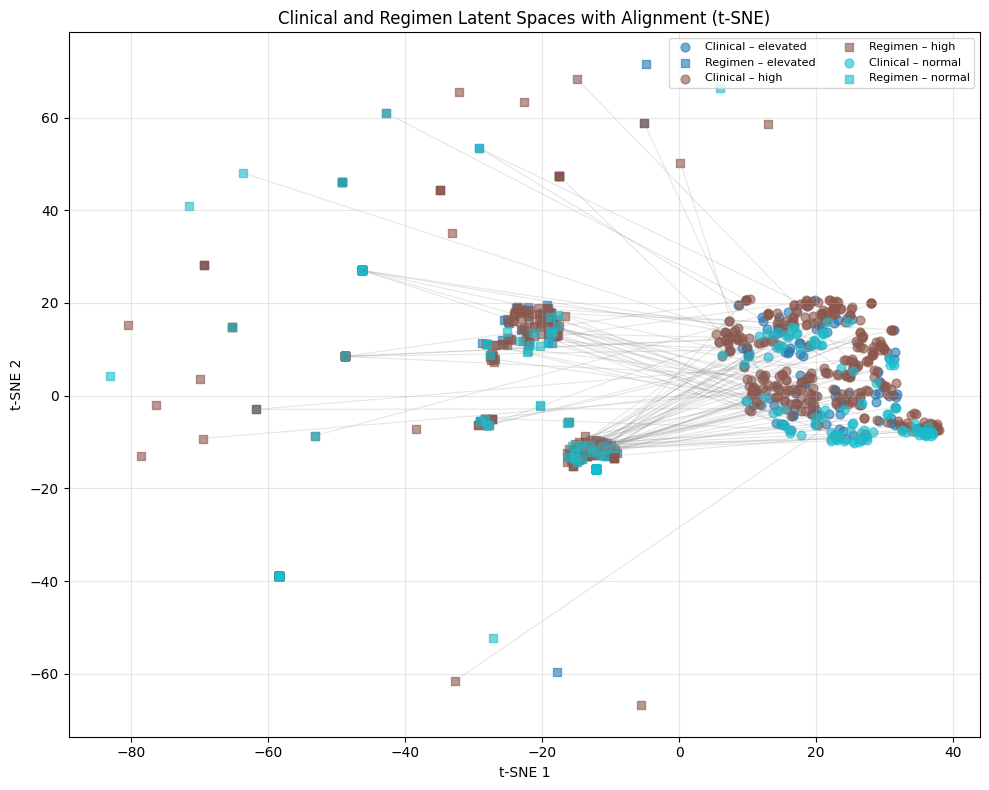

✅ Joint t‑SNE plot saved.

🎨 Joint UMAP: Clinical + Regimen Latents


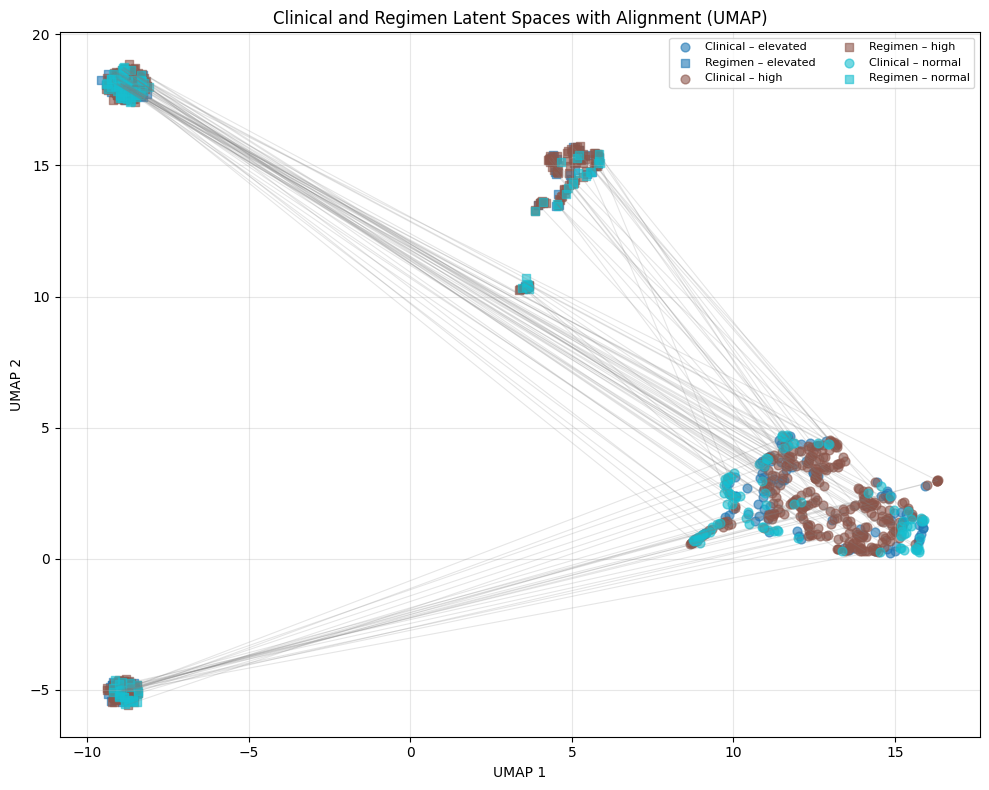

✅ Joint UMAP plot saved.

📊 THRESHOLD ANALYSIS

Effect of different thresholds:


Evaluating v11: 100%|██████████| 29/29 [00:02<00:00, 11.67it/s]



MAPCT‑v11 (GNN‑Transformer) Test Evaluation
Threshold: 0.1
Precision (micro): 0.2017
Recall    (micro): 0.7517
F1‑score  (micro): 0.3180
Accuracy (overall): 0.9598
Clinical‑Drug Alignment (mean cosine): 0.3092
Generation Diversity (mean pairwise Jaccard distance): 0.3332
Threshold 0.1: F1=0.3180, Precision=0.2017, Recall=0.7517


Evaluating v11: 100%|██████████| 29/29 [00:02<00:00, 11.59it/s]



MAPCT‑v11 (GNN‑Transformer) Test Evaluation
Threshold: 0.2
Precision (micro): 0.2937
Recall    (micro): 0.6769
F1‑score  (micro): 0.4097
Accuracy (overall): 0.9757
Clinical‑Drug Alignment (mean cosine): 0.3092
Generation Diversity (mean pairwise Jaccard distance): 0.2984
Threshold 0.2: F1=0.4097, Precision=0.2937, Recall=0.6769


...


MAPCT‑v11 (GNN‑Transformer) Test Evaluation
Threshold: 0.3
Precision (micro): 0.3989
Recall    (micro): 0.6340
F1‑score  (micro): 0.4897
Accuracy (overall): 0.9835
Clinical‑Drug Alignment (mean cosine): 0.3092
Generation Diversity (mean pairwise Jaccard distance): 0.3290
Threshold 0.3: F1=0.4897, Precision=0.3989, Recall=0.6340


Evaluating v11: 100%|██████████| 29/29 [00:02<00:00, 10.48it/s]



MAPCT‑v11 (GNN‑Transformer) Test Evaluation
Threshold: 0.4
Precision (micro): 0.5627
Recall    (micro): 0.5493
F1‑score  (micro): 0.5559
Accuracy (overall): 0.9891
Clinical‑Drug Alignment (mean cosine): 0.3092
Generation Diversity (mean pairwise Jaccard distance): 0.2838
Threshold 0.4: F1=0.5559, Precision=0.5627, Recall=0.5493


Evaluating v11: 100%|██████████| 29/29 [00:03<00:00,  8.52it/s]



MAPCT‑v11 (GNN‑Transformer) Test Evaluation
Threshold: 0.5
Precision (micro): 0.6954
Recall    (micro): 0.4861
F1‑score  (micro): 0.5722
Accuracy (overall): 0.9909
Clinical‑Drug Alignment (mean cosine): 0.3092
Generation Diversity (mean pairwise Jaccard distance): 0.1594
Threshold 0.5: F1=0.5722, Precision=0.6954, Recall=0.4861
Checkpoint saved to /content/drive/MyDrive/khezri/mapct_v11_final.pt

✅ MAPCT-v11-GN/T COMPLETE - All visualizations saved


In [27]:
if __name__ == "__main__":
    print("\n🚀 MAPCT-v11-GN/T (Leakage-free, Padding-fixed)")

    # Build embedding matrix with dummy row for padding index 0
    drug_embedding_matrix = torch.stack([drug_embeddings[d] for d in drug_vocab]).float()
    dummy_row = torch.zeros(1, drug_embedding_matrix.shape[1])
    drug_embedding_matrix = torch.cat([dummy_row, drug_embedding_matrix], dim=0)
    print(f"Drug embedding matrix shape: {drug_embedding_matrix.shape}")

    clin_dim = X_train.shape[1]
    model = MAPCTv11Hybrid(
        clin_dim=clin_dim,
        num_drugs=original_num_drugs,
        drug_graph_edge_index=drug_edge_index,
        drug_graph_weights=drug_edge_weights,
        drug_embedding_matrix=drug_embedding_matrix,
        latent_dim=128, gnn_type='gat', n_gnn_layers=2, n_transformer_layers=2,
        n_heads=4, max_drugs=MAX_DRUGS, fusion_dim=256
    ).to(device)
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    trainer = MAPCTv11Trainer(model, device, drug_vocab, drug_to_idx, drug_edge_index)

    CHECKPOINT_PATH = '/content/drive/MyDrive/khezri/mapct_v11_final.pt'

    # Check if we should retrain or load existing
    retrain = True  # Set to False to load existing model
    if os.path.exists(CHECKPOINT_PATH) and not retrain:
        print(f"\n📂 Loading existing checkpoint from {CHECKPOINT_PATH}")
        trainer.load_checkpoint(CHECKPOINT_PATH)
    else:
        if os.path.exists(CHECKPOINT_PATH):
            print(f"\n⚠️ Old checkpoint found – removing to force retraining with history.")
            os.remove(CHECKPOINT_PATH)

        print("\n🎯 STARTING TRAINING (epochs=50, patience=10)")
        history = trainer.train(train_loader, val_loader, epochs=50, patience=10)
        trainer.save_checkpoint(CHECKPOINT_PATH)
        print(f"✅ Model saved to {CHECKPOINT_PATH}")

    # ========== DEBUG LATENT COLLECTION ==========
    print("\n" + "="*60)
    print("🔍 DEBUGGING LATENT COLLECTION")
    print("="*60)
    z_clin_debug, z_reg_debug = debug_latent_collection(trainer, test_loader, device)

    # ========== COMPLETE VISUALIZATION SUITE ==========
    print("\n" + "="*60)
    print("GENERATING COMPLETE VISUALIZATION SUITE")
    print("="*60)

    # 1. Training history plots (only if trained)
    if trainer.history.get('loss'):
        plot_training_history(trainer)
        plot_smoothed_history(trainer, window=5)
    else:
        print("⚠️ No training history found - skipping training plots")

    # 2. Alignment analysis
    visualize_alignment(trainer, test_loader, device)

    # 3. Latent space visualizations (FIXED VERSIONS)
    print("\n🎨 Generating latent space visualizations...")
    visualize_latent_spaces(trainer, test_loader, test_df, device, max_samples=500)
    visualize_tsne_umap(trainer, test_loader, test_df, device, max_samples=500)

    # 4. Full evaluation metrics
    print("\n📊 Running comprehensive evaluation...")
    results = evaluate_mapct_v11(
        trainer=trainer,
        test_loader=test_loader,
        drug_vocab=drug_vocab,
        idx_to_drug=idx_to_drug,
        device=device,
        threshold=0.3,
        num_stochastic=5
    )
    print("\n📊 Full evaluation results:", results)

    # 5. Patient recommendations
    print("\n👥 Generating patient recommendations...")
    show_patient_recommendation(trainer, test_loader, test_df, drug_to_idx, idx_to_drug,
                                threshold=0.3, batch_size=BATCH_SIZE)

    # 6. Additional analysis for imbalanced predictions
    print("\n" + "="*60)
    print("📈 PREDICTION DISTRIBUTION ANALYSIS")
    print("="*60)

    # Analyze prediction distribution on test set
    trainer.model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            clinical = batch['clinical'].to(device)
            mech_tensor = batch['mech_tensor'].to(device)
            mech_mask = batch['mech_mask'].to(device)
            drug_indices = batch['drug_indices'].to(device)

            logits, _, _, _, _ = trainer.model(clinical, mech_tensor, mech_mask, drug_indices)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(batch['label'].numpy().flatten())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram of predictions
    axes[0].hist(all_probs[all_labels == 0], bins=50, alpha=0.5, label='Negative (No Drug)', density=True)
    axes[0].hist(all_probs[all_labels == 1], bins=50, alpha=0.5, label='Positive (Drug Present)', density=True)
    axes[0].set_xlabel('Prediction Probability')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Prediction Distribution by True Class')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Precision-Recall style curve
    thresholds = np.linspace(0, 1, 50)
    precisions = []
    recalls = []
    for thresh in thresholds:
        preds = (all_probs > thresh).astype(int)
        precisions.append(precision_score(all_labels, preds, zero_division=0))
        recalls.append(recall_score(all_labels, preds, zero_division=0))

    axes[1].plot(thresholds, precisions, 'b-', label='Precision')
    axes[1].plot(thresholds, recalls, 'r-', label='Recall')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('Score')
    axes[1].set_title('Precision/Recall vs Threshold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('prediction_distribution_analysis.png', dpi=150)
    plt.show()

    print(f"\n📊 Dataset Statistics:")
    print(f"   Total predictions: {len(all_probs)}")
    print(f"   Positive rate (true): {all_labels.mean():.4f}")
    print(f"   Mean prediction probability: {all_probs.mean():.4f}")
    print(f"   Median prediction probability: {np.median(all_probs):.4f}")

    # 7. Advanced alignment visualizations
    print("\n" + "="*60)
    print("🎨 ADVANCED ALIGNMENT VISUALIZATIONS")
    print("="*60)

    # Heatmap of correlations
    visualize_clinical_drug_alignment_heatmap(trainer, test_loader, device)

    # Joint alignment with arrows
    visualize_joint_alignment_with_arrows(trainer, test_loader, test_df, device, max_samples=100)

    # Alignment by category
    visualize_alignment_by_category(trainer, test_loader, test_df, device)

    # ========== NEW: Joint latent space visualisations ==========
    print("\n🎨 Generating joint latent space plots (PCA, t‑SNE, UMAP)...")
    visualize_joint_pca(trainer, test_loader, test_df, device,
                        max_samples=500, save_path='joint_pca.png')
    visualize_joint_tsne(trainer, test_loader, test_df, device,
                        max_samples=500, perplexity=30, save_path='joint_tsne.png')
    if UMAP_AVAILABLE:
        visualize_joint_umap(trainer, test_loader, test_df, device,
                            max_samples=500, n_neighbors=15, min_dist=0.1,
                            save_path='joint_umap.png')

    # 8. Threshold analysis
    print("\n" + "="*60)
    print("📊 THRESHOLD ANALYSIS")
    print("="*60)

    thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
    print("\nEffect of different thresholds:")
    for thresh in thresholds:
        results_thresh = evaluate_mapct_v11(
            trainer=trainer,
            test_loader=test_loader,
            drug_vocab=drug_vocab,
            idx_to_drug=idx_to_drug,
            device=device,
            threshold=thresh,
            num_stochastic=5
        )
        print(f"Threshold {thresh}: F1={results_thresh['f1']:.4f}, Precision={results_thresh['precision']:.4f}, Recall={results_thresh['recall']:.4f}")

    # Final save
    trainer.save_checkpoint(CHECKPOINT_PATH)

    print("\n" + "="*80)
    print("✅ MAPCT-v11-GN/T COMPLETE - All visualizations saved")
    print("="*80)